In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# To filter warnings on updated python versions
import warnings
warnings.filterwarnings('ignore')

# Library to split data, impute missing values
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# To tune different models
from sklearn.model_selection import GridSearchCV

# To measure classification performance
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Libraries to build Decision Tree and different ensemble classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier

# To build model for statistical analysis and prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression

# To install xgboost library
from xgboost import XGBClassifier

In [89]:
df = pd.read_csv("EasyVisa.csv")

In [91]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [93]:
#Checking the shape of the data

print("There are",df.shape[0],"rows and",df.shape[1],"columns.")

There are 25480 rows and 12 columns.


In [95]:
#Checking the data types of the columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [97]:
#Check for missing values in the data

df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [99]:
#Check for duplicate rows in the data

df.duplicated().sum()

0

In [101]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [103]:
# Dropping the column with all unique values
df = df.drop(['case_id'], axis=1)

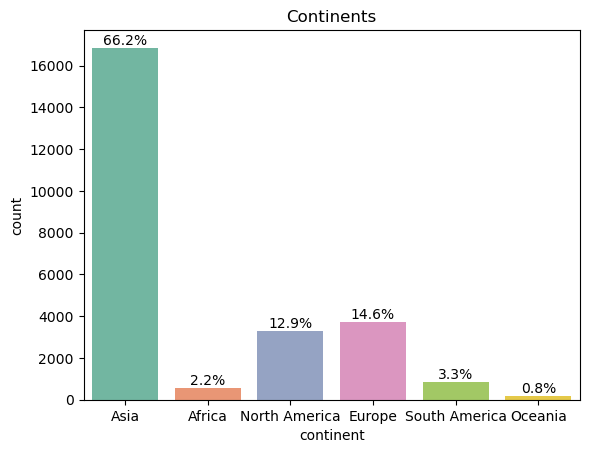

In [105]:
#Univariate Analysis
#Exploring individual variables (both categorical and numerical), highlighting any findings or outliers in the data
#Continent Uni_Analysis
ax = sns.countplot(data=df, x='continent', palette='Set2')

# Title and grid
plt.title("Continents")
plt.grid(False)

# Add percentage labels
total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()                  
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

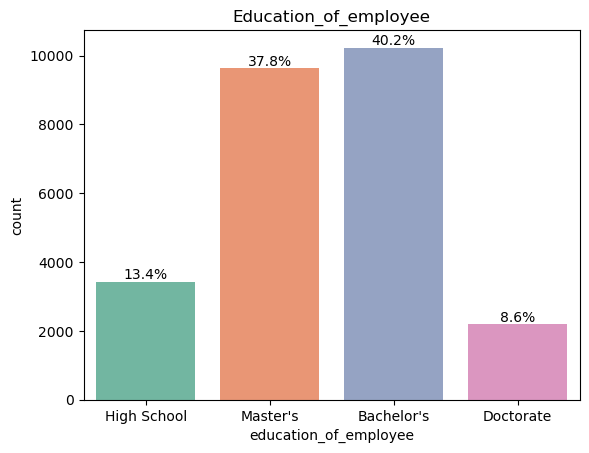

In [107]:
#Education_of_employee Uni_Analysis
ax = sns.countplot(data=df, x='education_of_employee', palette='Set2')

# Title and grid
plt.title("Education_of_employee")
plt.grid(False)

# Add percentage labels
total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()                  
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

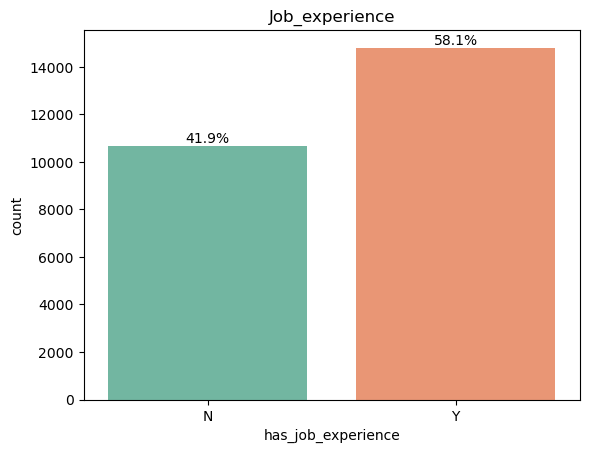

In [108]:
#Job_experience Uni_Analysis
ax = sns.countplot(data=df, x='has_job_experience', palette='Set2')

# Title and grid
plt.title("Job_experience")
plt.grid(False)

# Add percentage labels
total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()                  
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

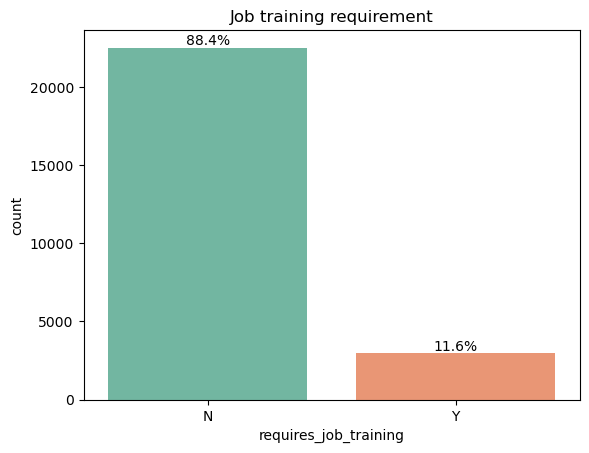

In [111]:
#Job training requirement Uni_Analysis
ax = sns.countplot(data=df, x='requires_job_training', palette='Set2')

# Title and grid
plt.title("Job training requirement")
plt.grid(False)

# Add percentage labels
total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()                  
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

In [113]:
# Looking at cases with negative values in number of employees
df.loc[df['no_of_employees']<=0]

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,Europe,Master's,N,N,-25,1980,Northeast,39452.9900,Year,Y,Certified
378,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.1400,Year,Y,Denied
832,South America,Master's,Y,N,-17,2002,South,129701.9400,Year,Y,Certified
2918,Asia,Master's,Y,N,-26,2005,Midwest,112799.4600,Year,Y,Certified
6439,Asia,Bachelor's,N,N,-14,2013,South,103.9700,Hour,Y,Denied
6634,Asia,Bachelor's,Y,N,-26,1923,West,5247.3200,Year,Y,Denied
7224,Europe,Doctorate,N,N,-25,1998,Midwest,141435.9500,Year,Y,Certified
7281,Asia,High School,N,N,-14,2000,Midwest,58488.5000,Year,Y,Denied
7318,Asia,Bachelor's,Y,Y,-26,2006,South,115005.6100,Year,Y,Certified
7761,Asia,Master's,N,N,-11,2009,Midwest,38457.5100,Year,Y,Certified


In [115]:
# Changing the negative values for positive in number of employees
df['no_of_employees'] = abs(df['no_of_employees'])

In [117]:
# Checking the change
df.loc[df['no_of_employees']<=0]

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status


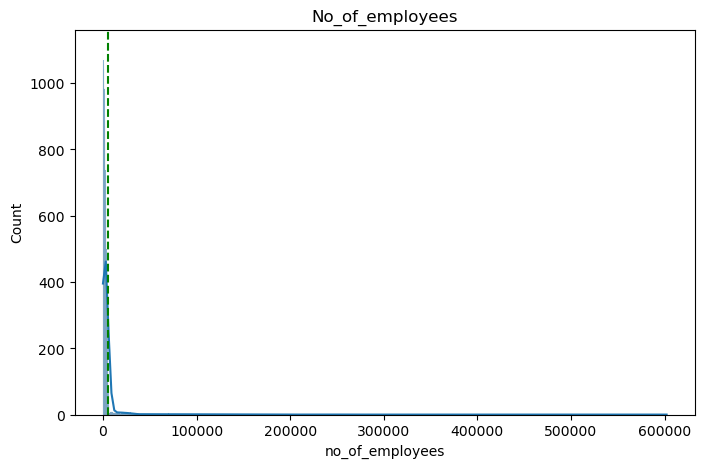

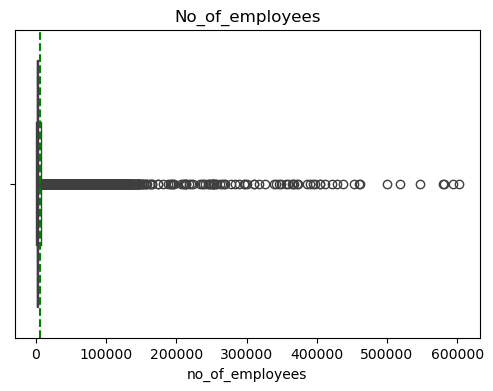

In [119]:
#No_of_employees Uni_Analysis
plt.figure(figsize=(8, 5))
plt.title("No_of_employees")
sns.histplot(data=df, x='no_of_employees', kde=True)
plt.axvline(x=df['no_of_employees'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("No_of_employees")
sns.boxplot(data=df, x='no_of_employees')
plt.axvline(x=df['no_of_employees'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

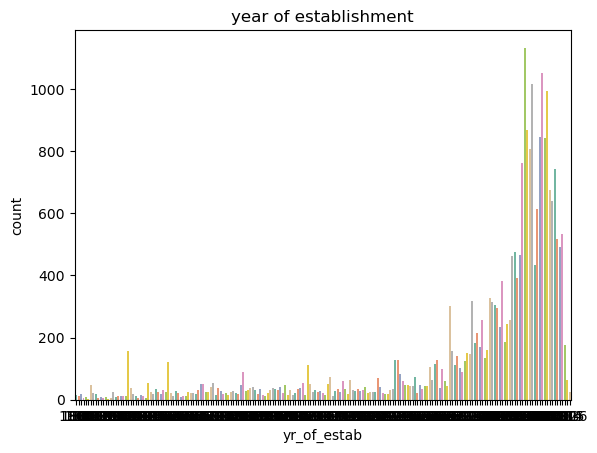

In [120]:
#year of establishment Uni_Analysis
sns.countplot(data=df,x='yr_of_estab',palette='Set2')
plt.title("year of establishment")
plt.grid(False)
plt.show()

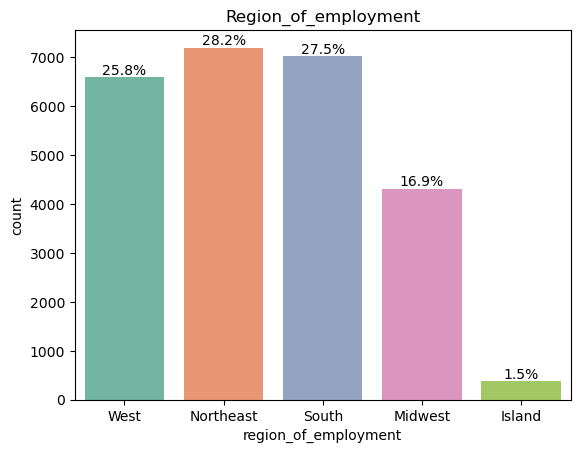

In [121]:
#Region_of_employment Uni_Analysis
ax = sns.countplot(data=df, x='region_of_employment', palette='Set2')

# Title and grid
plt.title("Region_of_employment")
plt.grid(False)

# Add percentage labels
total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()                  
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

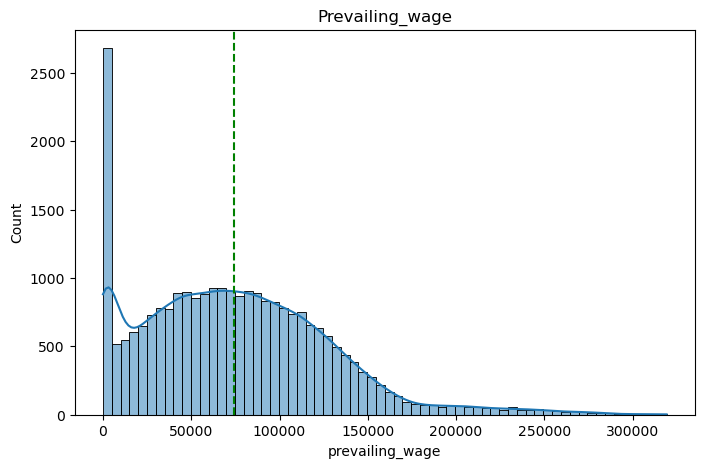

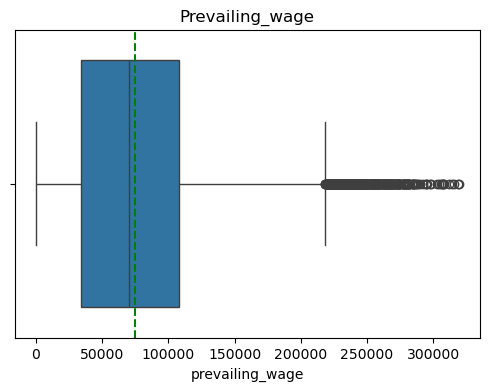

In [122]:
#Prevailing_wage Uni_Analysis
plt.figure(figsize=(8, 5))
plt.title("Prevailing_wage")
sns.histplot(data=df, x='prevailing_wage', kde=True)
plt.axvline(x=df['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("Prevailing_wage")
sns.boxplot(data=df, x='prevailing_wage')
plt.axvline(x=df['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

In [127]:
df.loc[df['prevailing_wage'] < 100].head(10)

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
338,Asia,Bachelor's,Y,N,2114,2012,Northeast,15.7716,Hour,Y,Certified
634,Asia,Master's,N,N,834,1977,Northeast,3.3188,Hour,Y,Denied
839,Asia,High School,Y,N,4537,1999,West,61.1329,Hour,Y,Denied
876,South America,Bachelor's,Y,N,731,2004,Northeast,82.0029,Hour,Y,Denied
995,Asia,Master's,N,N,302,2000,South,47.4872,Hour,Y,Certified
1144,Asia,Master's,N,N,3542,2001,Northeast,48.0065,Hour,Y,Denied
1147,North America,Bachelor's,Y,N,169,2007,Northeast,99.3492,Hour,Y,Denied
1215,Asia,Bachelor's,N,N,1814,2002,Northeast,10.5551,Hour,Y,Denied
1238,South America,Doctorate,N,N,1998,1992,West,16.4637,Hour,Y,Denied
1326,Asia,Master's,N,N,2198,2004,Northeast,89.5992,Hour,Y,Denied


In [129]:
df.loc[df["prevailing_wage"] < 5000, "unit_of_wage"].value_counts()

unit_of_wage
Hour     2157
Year      518
Week        4
Month       3
Name: count, dtype: int64

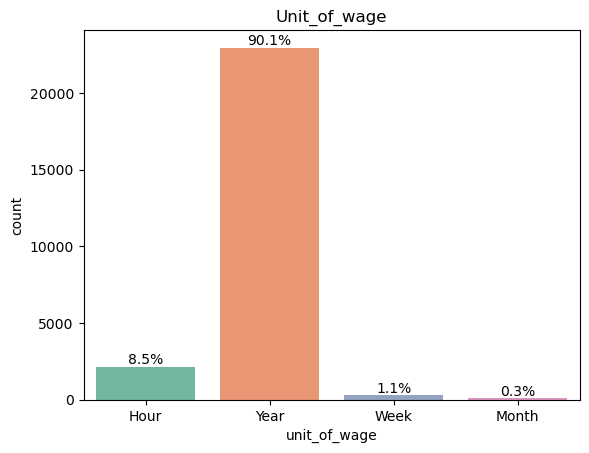

In [131]:
#Unit_of_wage Uni_Analysis
ax = sns.countplot(data=df, x='unit_of_wage', palette='Set2')

# Title and grid
plt.title("Unit_of_wage")
plt.grid(False)

# Add percentage labels
total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()                  
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

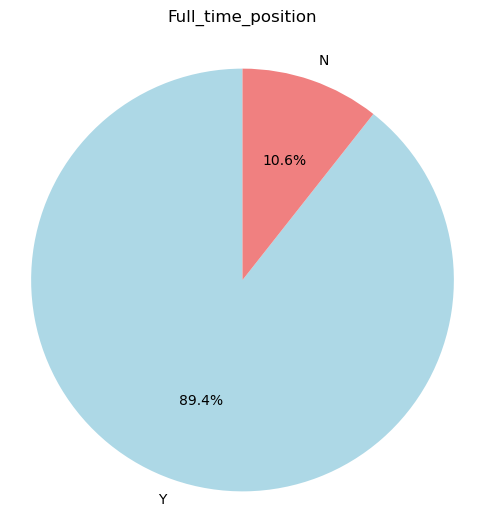

In [133]:
full_time_position = df['full_time_position'].value_counts()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(full_time_position, 
        labels=full_time_position.index, 
        autopct='%1.1f%%',      
        startangle=90,          
        colors=['lightblue', 'lightcoral', 'lightgreen'])

plt.title('Full_time_position',pad=20)
plt.axis('equal')
plt.show()

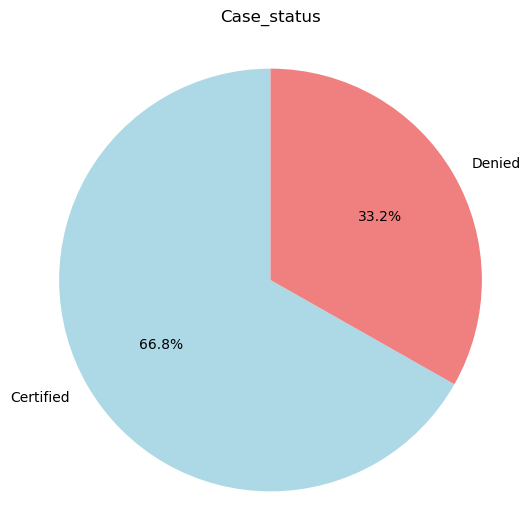

In [135]:
case_status = df['case_status'].value_counts()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(case_status, 
        labels=case_status.index, 
        autopct='%1.1f%%',      
        startangle=90,          
        colors=['lightblue', 'lightcoral', 'lightgreen'])

plt.title('Case_status',pad=20)
plt.axis('equal')
plt.show()

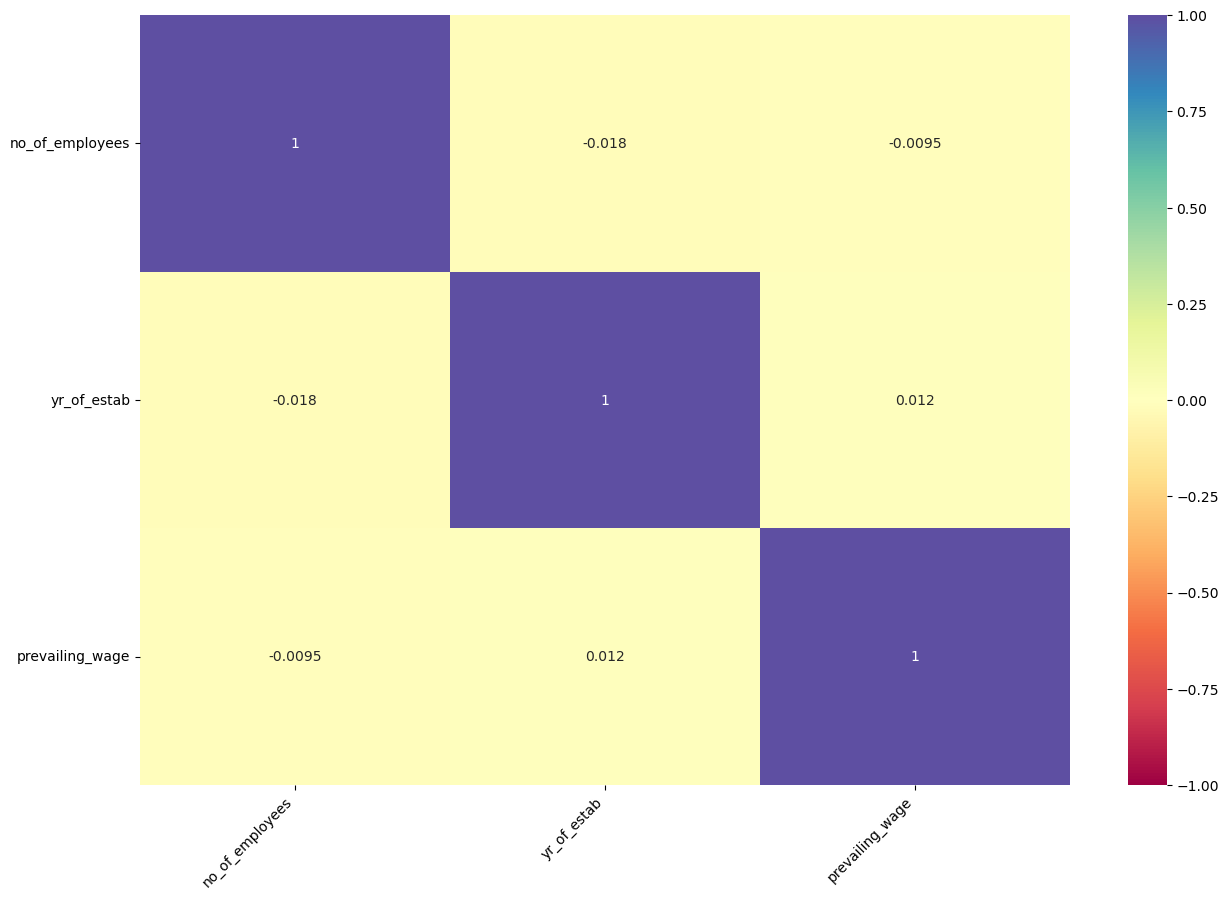

In [137]:
#Bivariate Analysis
##Explore all the numerical variables and check their association with each other

N_df=df.select_dtypes(include='number')

plt.figure(figsize=(15, 10))
sns.heatmap(
    N_df.corr(),
    annot=True,
    cmap='Spectral',
    vmin=-1,
    vmax=1,
    annot_kws={"size": 10}  
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)              
plt.show()

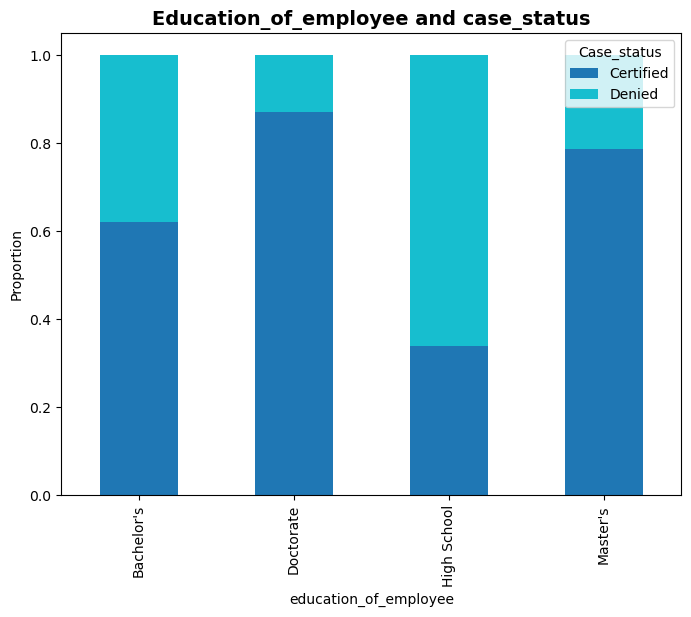

case_status            Certified  Denied    All
education_of_employee                          
Bachelor's                  6367    3867  10234
Doctorate                   1912     280   2192
High School                 1164    2256   3420
Master's                    7575    2059   9634
All                        17018    8462  25480


In [139]:
 #Bivariate Analysis on education_of_employee and case_status
ct = pd.crosstab(df['education_of_employee'], df['case_status'], normalize='index')

# Plot stacked bar
ct.plot(kind='bar', stacked=True, figsize=(8,6), colormap="tab10")

plt.title("Education_of_employee and case_status", fontsize=14, fontweight='bold')
plt.xlabel("education_of_employee")
plt.ylabel("Proportion")
plt.legend(title="Case_status")
plt.show()


ct = pd.crosstab(
    df["education_of_employee"],
    df["case_status"],
    margins=True,            
    margins_name="All"          
)

print(ct)

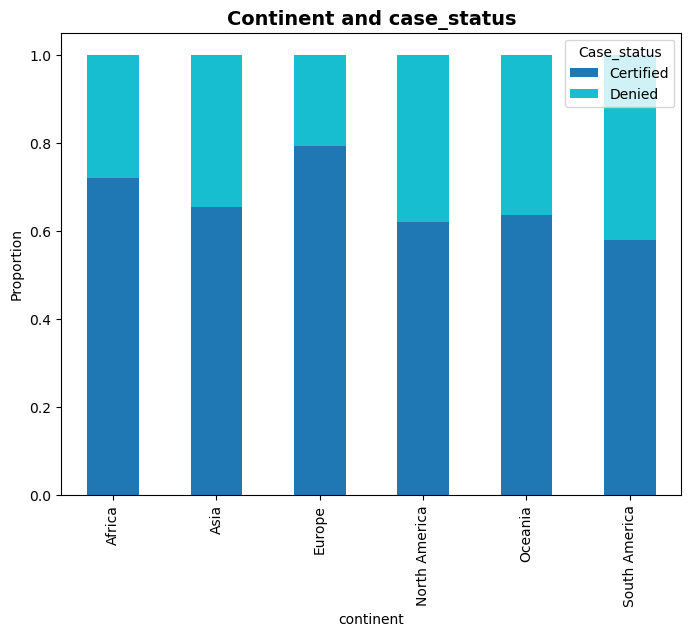

case_status    Certified  Denied    All
continent                              
Africa               397     154    551
Asia               11012    5849  16861
Europe              2957     775   3732
North America       2037    1255   3292
Oceania              122      70    192
South America        493     359    852
All                17018    8462  25480


In [140]:
 #Bivariate Analysis on continent and case_status
ct = pd.crosstab(df['continent'], df['case_status'], normalize='index')

# Plot stacked bar
ct.plot(kind='bar', stacked=True, figsize=(8,6), colormap="tab10")

plt.title("Continent and case_status", fontsize=14, fontweight='bold')
plt.xlabel("continent")
plt.ylabel("Proportion")
plt.legend(title="Case_status")
plt.show()


ct = pd.crosstab(
    df["continent"],
    df["case_status"],
    margins=True,            
    margins_name="All"          
)

print(ct)

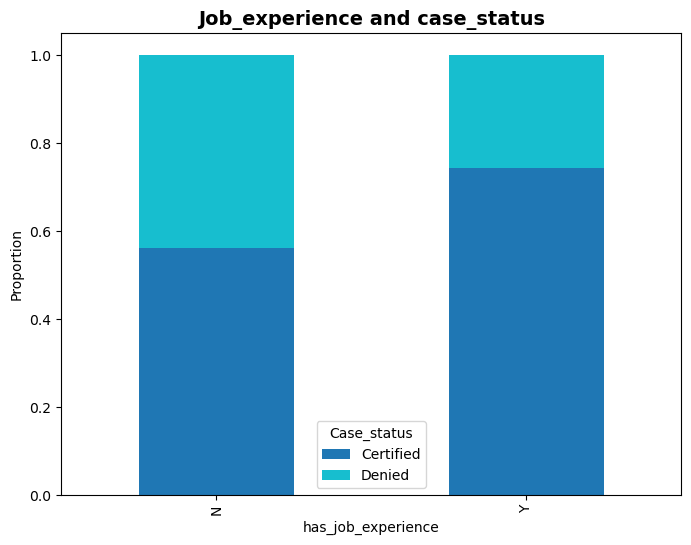

case_status         Certified  Denied    All
has_job_experience                          
N                        5994    4684  10678
Y                       11024    3778  14802
All                     17018    8462  25480


In [142]:
 #Bivariate Analysis on Job_experience and case_status
ct = pd.crosstab(df['has_job_experience'], df['case_status'], normalize='index')

# Plot stacked bar
ct.plot(kind='bar', stacked=True, figsize=(8,6), colormap="tab10")

plt.title("Job_experience and case_status", fontsize=14, fontweight='bold')
plt.xlabel("has_job_experience")
plt.ylabel("Proportion")
plt.legend(title="Case_status")
plt.show()


ct = pd.crosstab(
    df["has_job_experience"],
    df["case_status"],
    margins=True,            
    margins_name="All"          
)

print(ct)

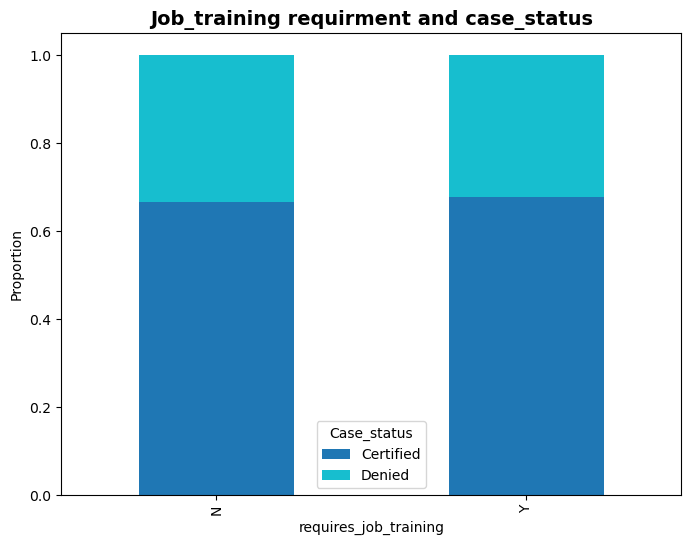

case_status            Certified  Denied    All
requires_job_training                          
N                          15012    7513  22525
Y                           2006     949   2955
All                        17018    8462  25480


In [144]:
 #Bivariate Analysis on Job_training requirment and case_status
ct = pd.crosstab(df['requires_job_training'], df['case_status'], normalize='index')

# Plot stacked bar
ct.plot(kind='bar', stacked=True, figsize=(8,6), colormap="tab10")

plt.title("Job_training requirment and case_status", fontsize=14, fontweight='bold')
plt.xlabel("requires_job_training")
plt.ylabel("Proportion")
plt.legend(title="Case_status")
plt.show()


ct = pd.crosstab(
    df["requires_job_training"],
    df["case_status"],
    margins=True,            
    margins_name="All"          
)

print(ct)

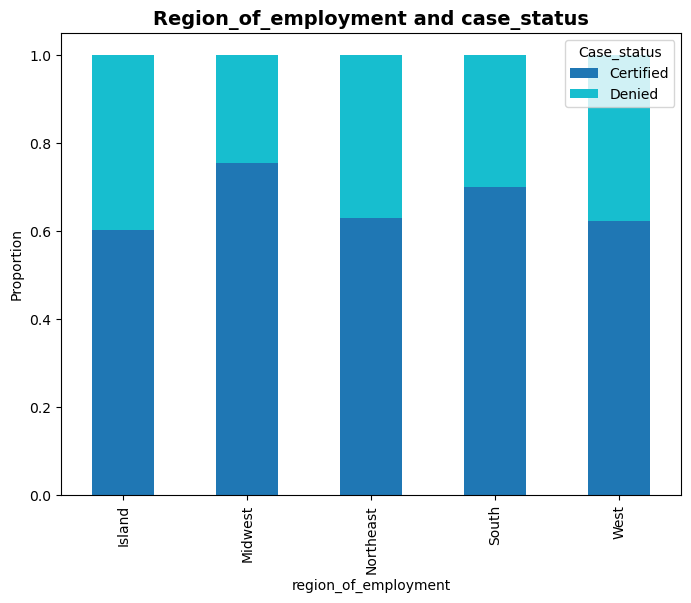

case_status           Certified  Denied    All
region_of_employment                          
Island                      226     149    375
Midwest                    3253    1054   4307
Northeast                  4526    2669   7195
South                      4913    2104   7017
West                       4100    2486   6586
All                       17018    8462  25480


In [146]:
 #Bivariate Analysis on region_of_employment and case_status
ct = pd.crosstab(df['region_of_employment'], df['case_status'], normalize='index')

# Plot stacked bar
ct.plot(kind='bar', stacked=True, figsize=(8,6), colormap="tab10")

plt.title("Region_of_employment and case_status", fontsize=14, fontweight='bold')
plt.xlabel("region_of_employment")
plt.ylabel("Proportion")
plt.legend(title="Case_status")
plt.show()


ct = pd.crosstab(
    df["region_of_employment"],
    df["case_status"],
    margins=True,            
    margins_name="All"          
)

print(ct)

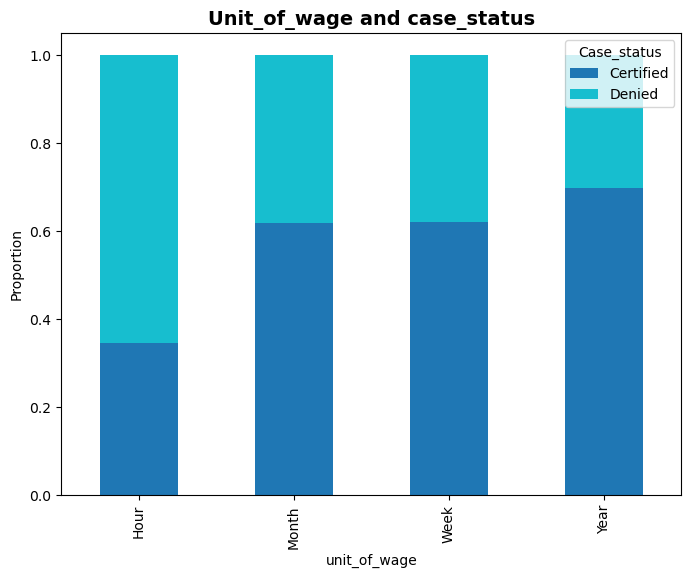

case_status   Certified  Denied    All
unit_of_wage                          
Hour                747    1410   2157
Month                55      34     89
Week                169     103    272
Year              16047    6915  22962
All               17018    8462  25480


In [148]:
#Bivariate Analysis on Unit_of_wage and case_status
ct = pd.crosstab(df['unit_of_wage'], df['case_status'], normalize='index')

# Plot stacked bar
ct.plot(kind='bar', stacked=True, figsize=(8,6), colormap="tab10")

plt.title("Unit_of_wage and case_status", fontsize=14, fontweight='bold')
plt.xlabel("unit_of_wage")
plt.ylabel("Proportion")
plt.legend(title="Case_status")
plt.show()


ct = pd.crosstab(
    df["unit_of_wage"],
    df["case_status"],
    margins=True,            
    margins_name="All"          
)

print(ct)

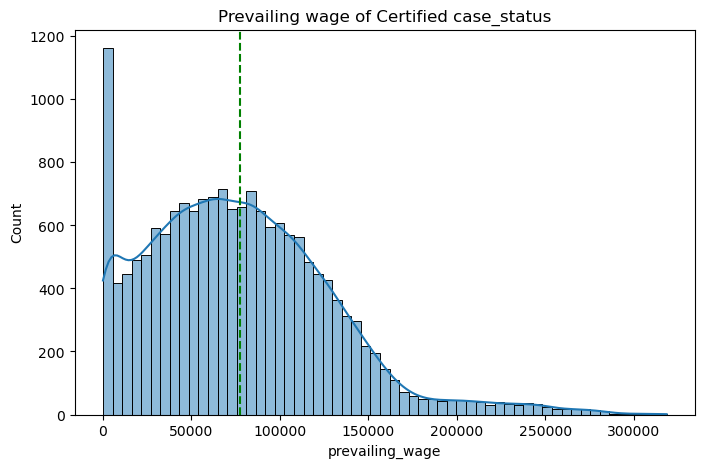

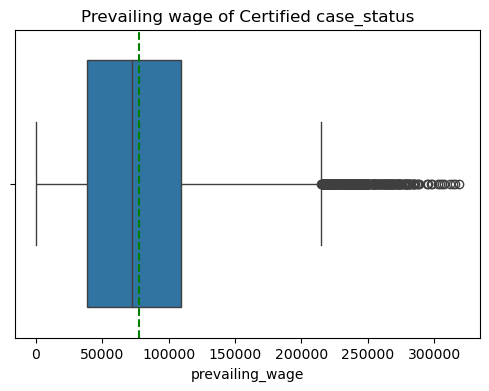

In [149]:
 ##creating a data frame for Certified case status
df_Certified = df.loc[df['case_status'] == 'Certified']

plt.figure(figsize=(8, 5))
plt.title("Prevailing wage of Certified case_status")
sns.histplot(data=df_Certified, x='prevailing_wage', kde=True)
plt.axvline(x=df_Certified['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("Prevailing wage of Certified case_status")
sns.boxplot(data=df_Certified, x='prevailing_wage')
plt.axvline(x=df_Certified['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

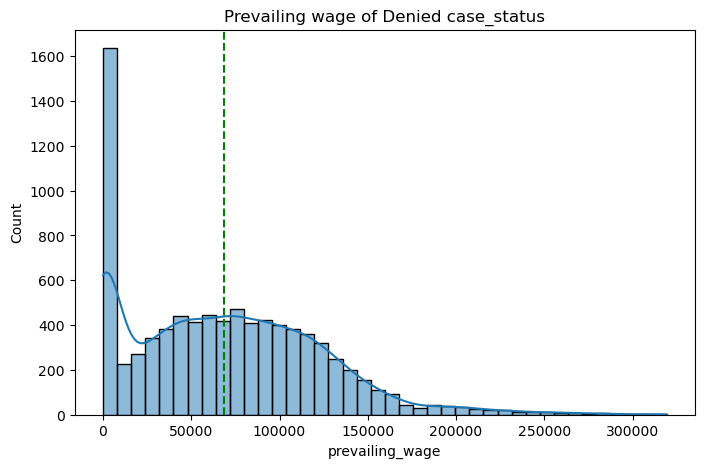

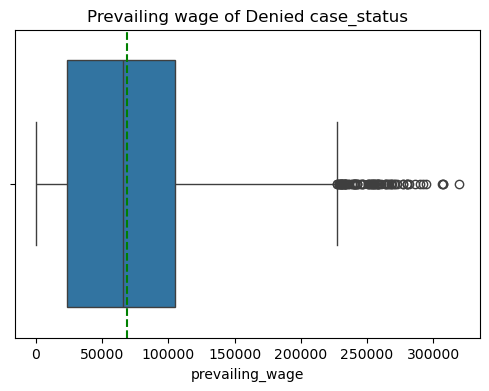

In [151]:
 ##creating a data frame for Denied case status
df_Denied = df.loc[df['case_status'] == 'Denied']

plt.figure(figsize=(8, 5))
plt.title("Prevailing wage of Denied case_status")
sns.histplot(data=df_Denied, x='prevailing_wage', kde=True)
plt.axvline(x=df_Denied['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("Prevailing wage of Denied case_status")
sns.boxplot(data=df_Denied, x='prevailing_wage')
plt.axvline(x=df_Denied['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

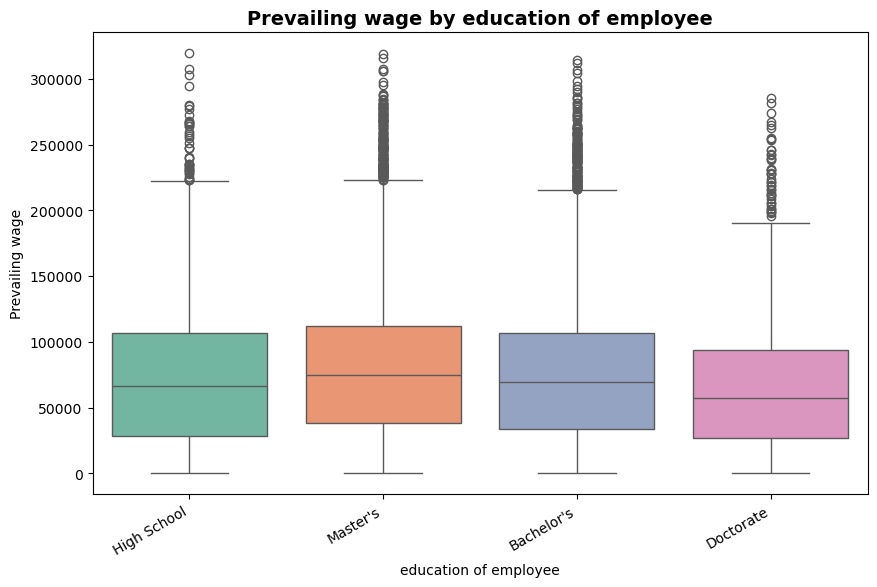

In [153]:
 ## Checking the Prevailing wage by education_of_employee
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df, 
    x='education_of_employee', 
    y='prevailing_wage', 
    palette="Set2" 
)

plt.title("Prevailing wage by education of employee", fontsize=14, fontweight='bold')
plt.xlabel("education of employee")
plt.ylabel("Prevailing wage")
plt.xticks(rotation=30, ha='right')
plt.show()

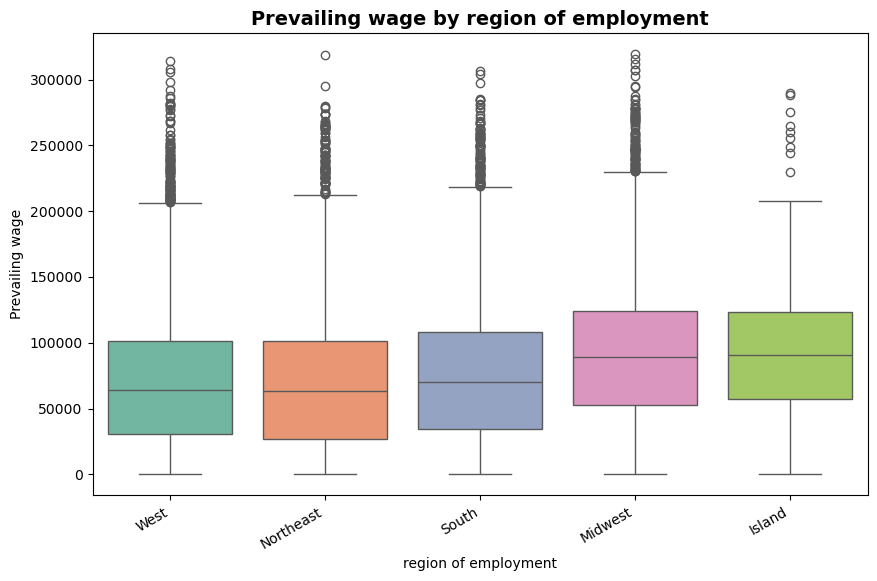

In [154]:
 ## Checking the Prevailing wage by region_of_employment
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df, 
    x='region_of_employment', 
    y='prevailing_wage', 
    palette="Set2" 
)

plt.title("Prevailing wage by region of employment", fontsize=14, fontweight='bold')
plt.xlabel("region of employment")
plt.ylabel("Prevailing wage")
plt.xticks(rotation=30, ha='right')
plt.show()

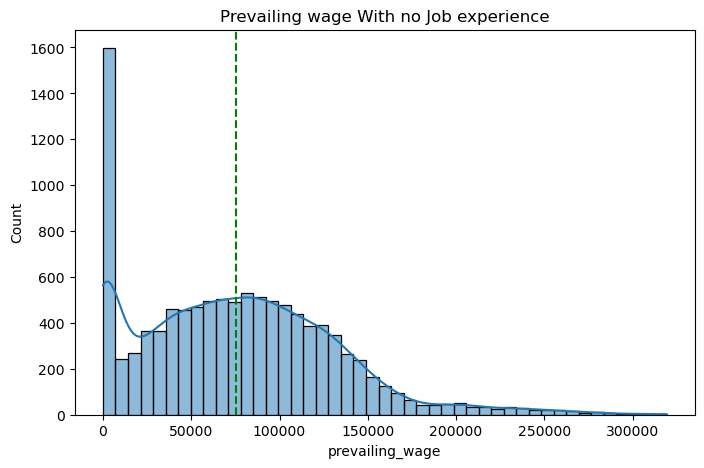

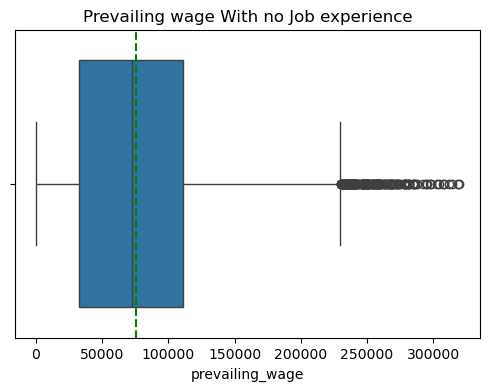

In [155]:
 ##creating a data frame for No job_experience
df_No = df.loc[df['has_job_experience'] == 'N']

plt.figure(figsize=(8, 5))
plt.title("Prevailing wage With no Job experience")
sns.histplot(data=df_No, x='prevailing_wage', kde=True)
plt.axvline(x=df_No['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("Prevailing wage With no Job experience")
sns.boxplot(data=df_No, x='prevailing_wage')
plt.axvline(x=df_No['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

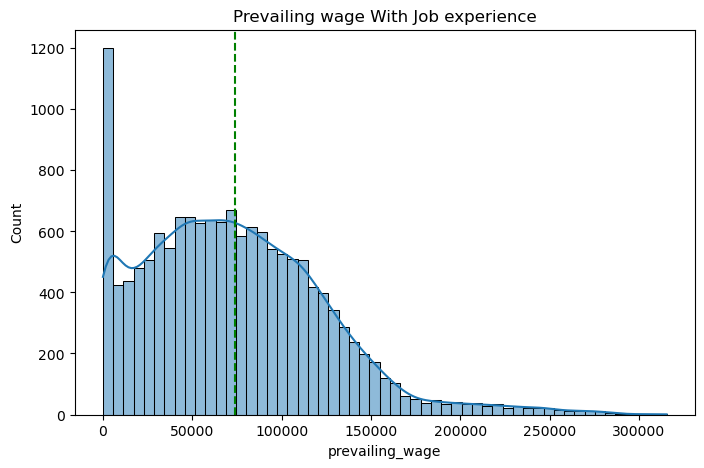

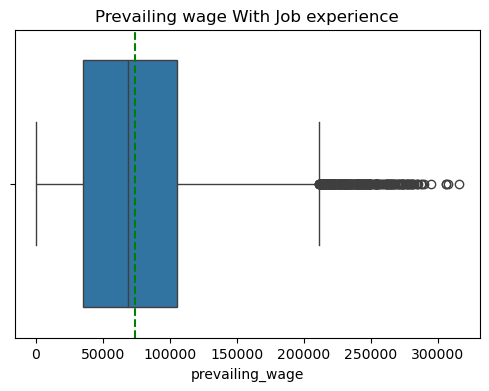

In [157]:
 ##creating a data frame for job_experience
df_Yes = df.loc[df['has_job_experience'] == 'Y']

plt.figure(figsize=(8, 5))
plt.title("Prevailing wage With Job experience")
sns.histplot(data=df_Yes, x='prevailing_wage', kde=True)
plt.axvline(x=df_Yes['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("Prevailing wage With Job experience")
sns.boxplot(data=df_Yes, x='prevailing_wage')
plt.axvline(x=df_Yes['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

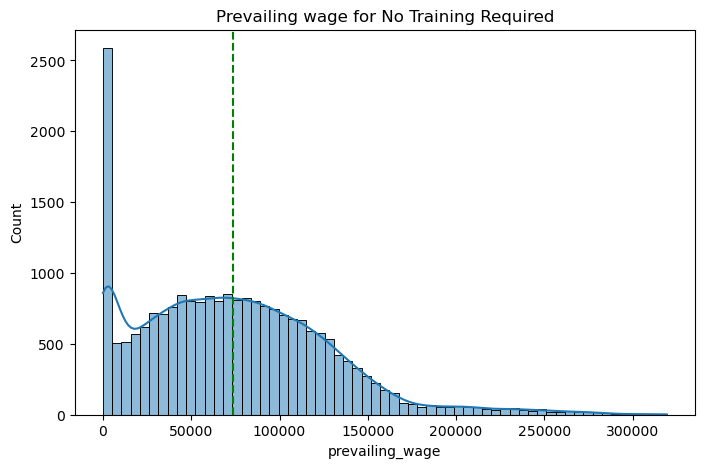

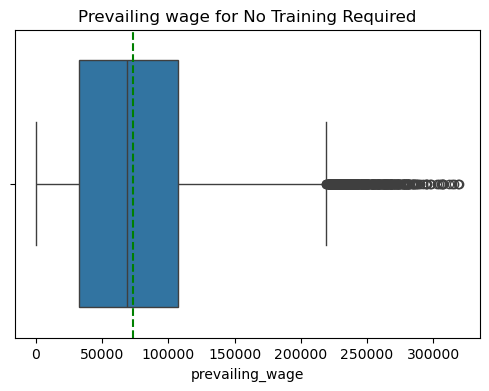

In [159]:
 ##creating a data frame for No Training Required
df_N = df.loc[df['requires_job_training'] == 'N']

plt.figure(figsize=(8, 5))
plt.title("Prevailing wage for No Training Required")
sns.histplot(data=df_N, x='prevailing_wage', kde=True)
plt.axvline(x=df_N['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("Prevailing wage for No Training Required")
sns.boxplot(data=df_N, x='prevailing_wage')
plt.axvline(x=df_N['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

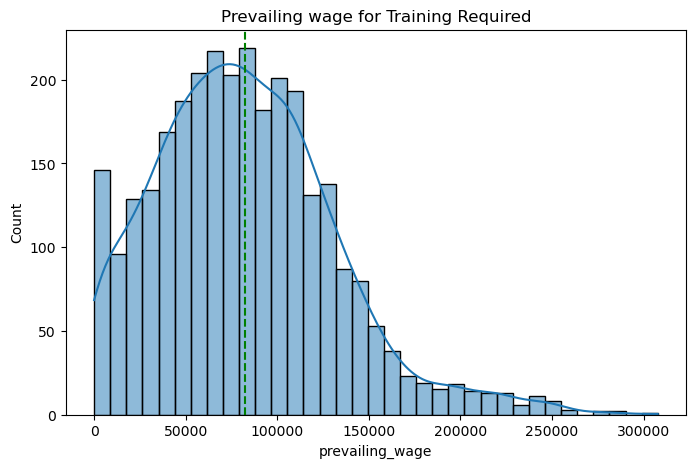

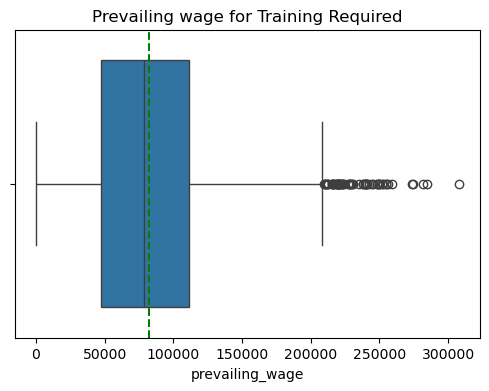

In [160]:
 ##creating a data frame for Training Required
df_Y = df.loc[df['requires_job_training'] == 'Y']

plt.figure(figsize=(8, 5))
plt.title("Prevailing wage for Training Required")
sns.histplot(data=df_Y, x='prevailing_wage', kde=True)
plt.axvline(x=df_Y['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

plt.figure(figsize=(6, 4))
plt.title("Prevailing wage for Training Required")
sns.boxplot(data=df_Y, x='prevailing_wage')
plt.axvline(x=df_Y['prevailing_wage'].mean(), color='green', linestyle='--', label='Mean')
plt.grid(False)
plt.show()

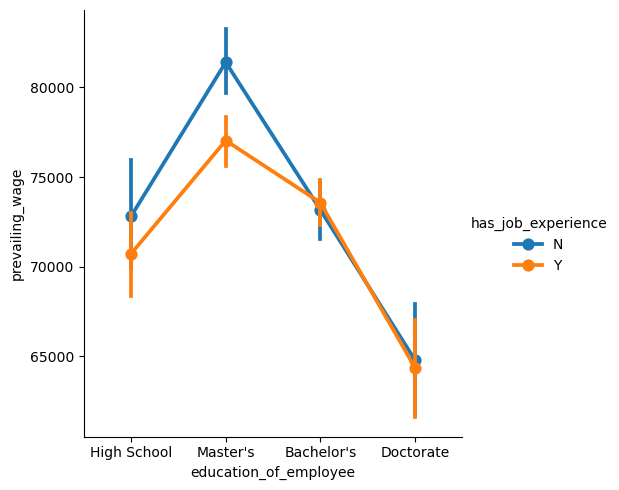

In [162]:
sns.catplot(data=df, x='education_of_employee', y='prevailing_wage', hue='has_job_experience', kind='point')
plt.show()

In [169]:
# Changing case status data type
df['case_status'] = df['case_status'].replace({'Denied': 0, 'Certified': 1})
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,0
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,1
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,0
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,0
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,1


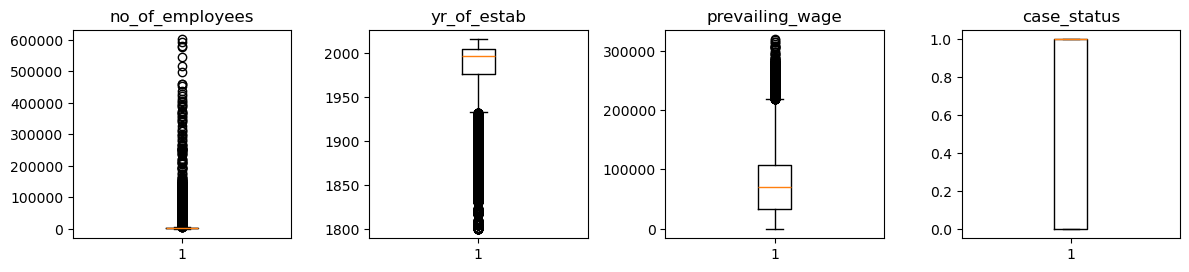

In [171]:
# outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 10))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [172]:
## Function to create confusion matrix
def make_confusion_matrix(model, X_test, y_actual, threshold=0.5):
    '''
    model : trained logistic regression model
    X_test : test features
    y_actual : true labels
    threshold : cutoff for classifying probabilities into 0/1
    '''
    # Get predicted probabilities
    y_prob = model.predict(X_test)
    
    # Convert to 0/1 using threshold
    y_predict = (y_prob >= threshold).astype(int)
    
    # Confusion matrix
    cm = metrics.confusion_matrix(y_actual, y_predict, labels=[0, 1])
    
    df_cm = pd.DataFrame(cm, 
                         index=["Actual - No","Actual - Yes"],
                         columns=['Predicted - No','Predicted - Yes'])
    
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap="Blues")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [173]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, make_scorer
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [177]:
#Splitting data into train and test
import statsmodels.api as sm 
from statsmodels.tools import add_constant

X = df.drop(["case_status"], axis=1) 
y = df["case_status"]

# adding a contstant to X variable
X = add_constant(X)

# creating dummies
X = pd.get_dummies(X,columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True,)

X = X.astype(float) #Making sure are data is in type float      

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y) 

In [179]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in test data =", X_test.shape[0])
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Number of rows in train data = 17836
Number of rows in test data = 7644
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64


#**Decision Tree Classifier-Original data**

In [182]:
# Fitting the model
dTree = DecisionTreeClassifier(random_state=1, class_weight="balanced")
dTree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

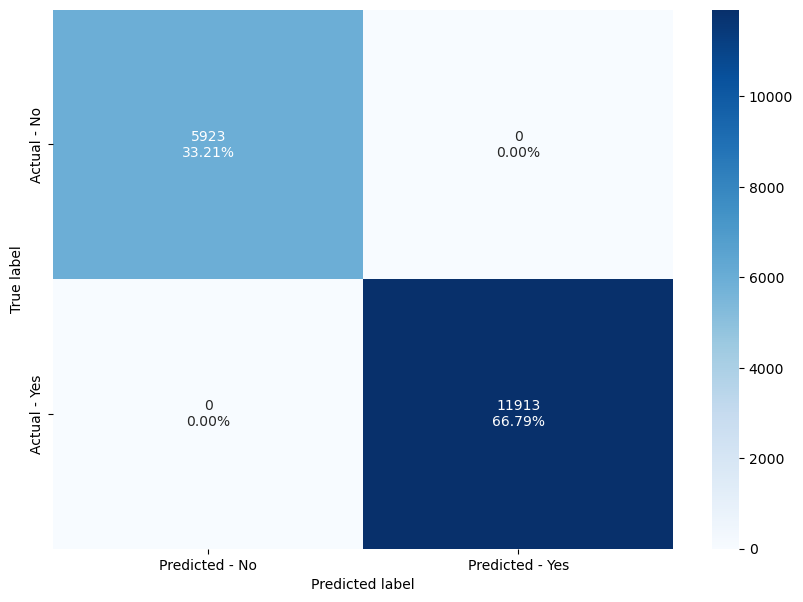

In [184]:
make_confusion_matrix(dTree, X_train, y_train, threshold=0.5)

In [186]:
print("Decision Tree Training performance model:")
model_performance_classification_statsmodels(dTree, X_train, y_train)

Decision Tree Training performance model:


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


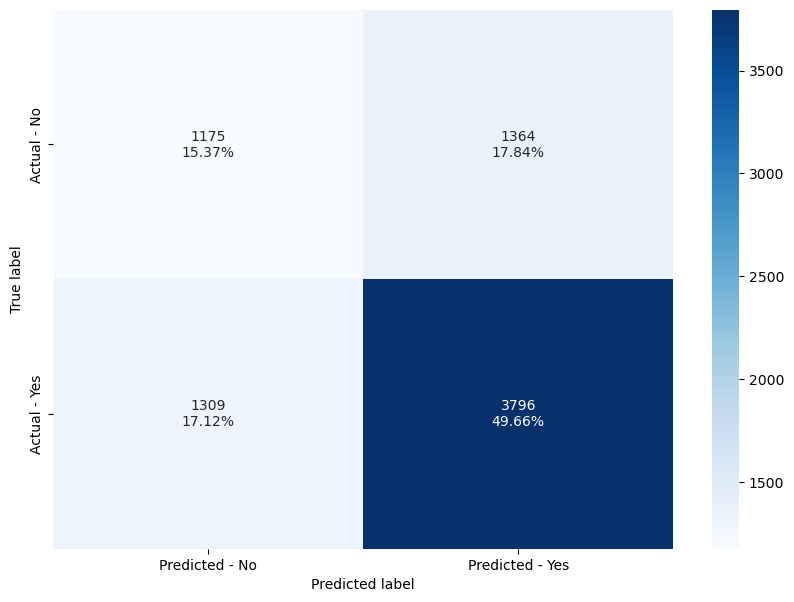

In [188]:
make_confusion_matrix(dTree, X_test, y_test, threshold=0.5)

In [175]:
print("Decision Tree Test performance model:")
model_performance_classification_statsmodels(dTree, X_test, y_test)

Decision Tree Test performance model:


,Accuracy,Recall,Precision,F1
0,0.650314,0.743585,0.735659,0.739601


In [181]:
#Hyperparameter tuning for decision tree

dTree_tuned = DecisionTreeClassifier(class_weight="balanced", random_state=1)

# Grid of parameters to choose from
parameters = {
    "max_depth": np.arange(10, 20, 5),
    "min_samples_leaf": [3, 5],
    "max_leaf_nodes": [2, 3, 5],
    "min_impurity_decrease": [0.0001, 0.001],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(dTree_tuned, parameters, scoring=acc_scorer, cv=5, n_jobs= -1, verbose = 2)
# verbose = 2 tells about the number of fits, which can give an idea of how long will the model take in tuning
# n_jobs = -1 so that all CPU cores can be run parallelly to optimize the Search

grid_obj = grid_obj.fit(X_train, y_train)

# Print the best combination of parameters
grid_obj.best_params_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


{'max_depth': 10,
 'max_leaf_nodes': 2,
 'min_impurity_decrease': 0.0001,
 'min_samples_leaf': 3}

In [183]:
grid_obj.best_score_

0.931923507999745

In [187]:
# Set the clf to the best combination of parameters
dTree_tuned1 = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=10,
    min_samples_leaf=3,
    max_leaf_nodes=2,
    min_impurity_decrease=0.0001
)

# Fit the best algorithm to the data
dTree_tuned1.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', max_depth=10, max_leaf_nodes=2,
                       min_impurity_decrease=0.0001, min_samples_leaf=3)

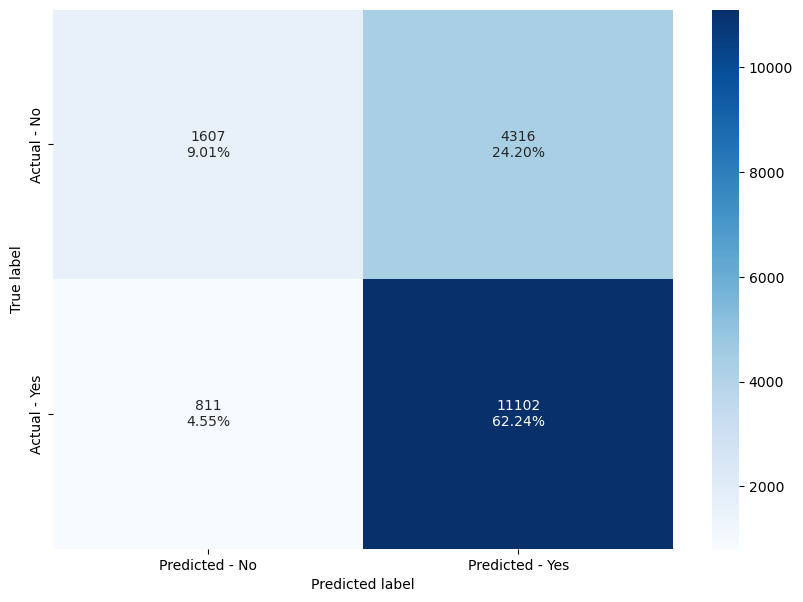

In [189]:
make_confusion_matrix(dTree_tuned1, X_train, y_train, threshold=0.5)

In [191]:
print("Tuned Decision Tree Training performance model:")
model_performance_classification_statsmodels(dTree_tuned1, X_train, y_train)

Tuned Decision Tree Training performance model:


,Accuracy,Recall,Precision,F1
0,0.712548,0.931923,0.720067,0.812411


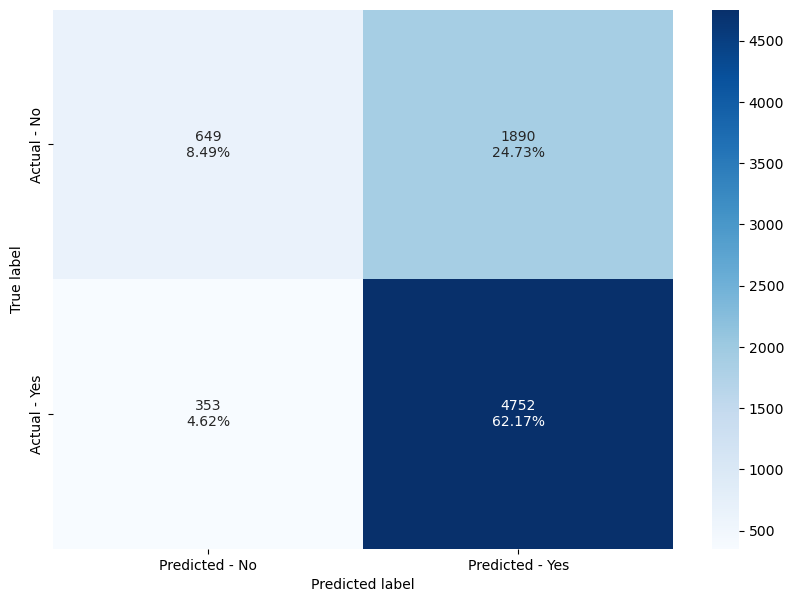

In [193]:
make_confusion_matrix(dTree_tuned1, X_test, y_test, threshold=0.5)

In [129]:
print("Tuned Decision Tree Test performance model:")
model_performance_classification_statsmodels(dTree_tuned, X_test, y_test)

Tuned Decision Tree Test performance model:


,Accuracy,Recall,Precision,F1
0,0.706567,0.930852,0.715447,0.809058


#**Bagging Classifier-Original data**

In [130]:
#base_estimator for bagging classifier is a decision tree by default
bagging_estimator=BaggingClassifier(random_state=1)
bagging_estimator.fit(X_train,y_train)

BaggingClassifier(random_state=1)

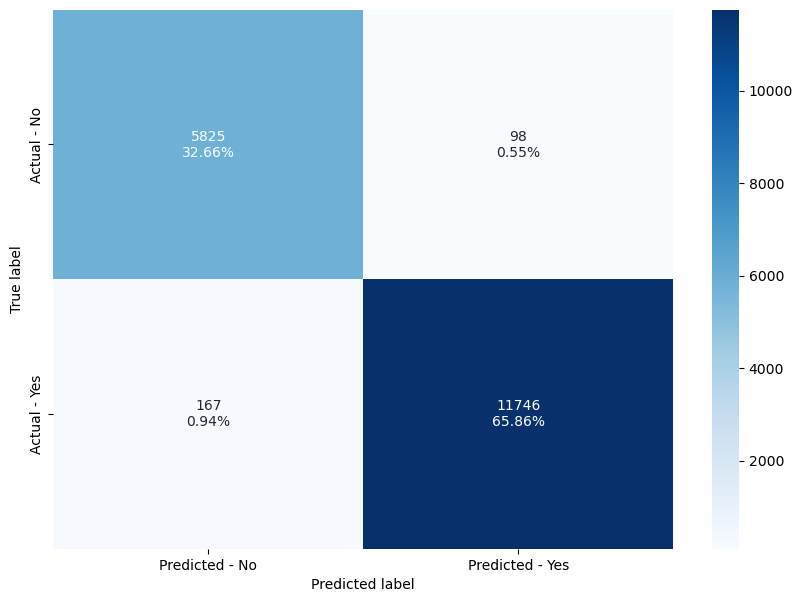

In [144]:
make_confusion_matrix(bagging_estimator, X_train, y_train, threshold=0.5)

In [179]:
print("Bagging training performance model:")
model_performance_classification_statsmodels(bagging_estimator, X_train, y_train)

Bagging training performance model:


,Accuracy,Recall,Precision,F1
0,0.985142,0.985982,0.991726,0.988845


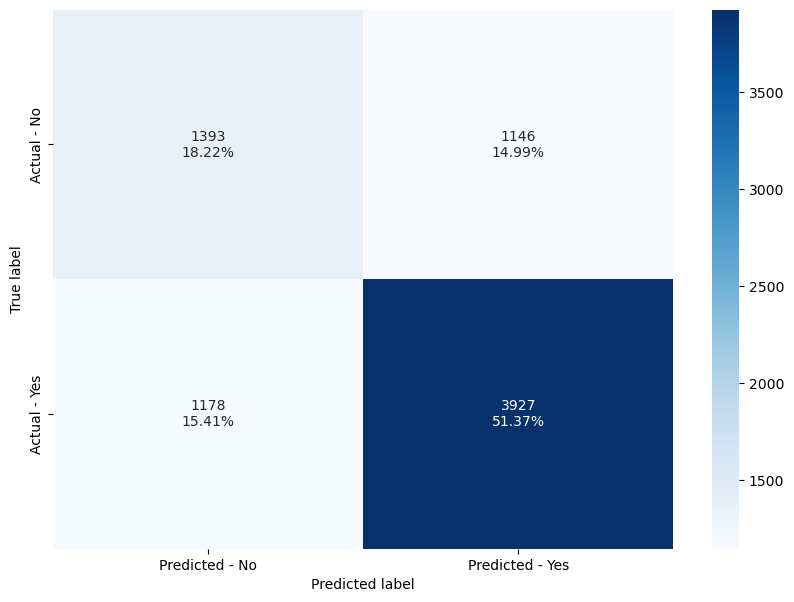

In [181]:
make_confusion_matrix(bagging_estimator, X_test, y_test, threshold=0.5)

In [183]:
print("Bagging test performance model:")
model_performance_classification_statsmodels(bagging_estimator, X_test, y_test)

Bagging test performance model:


,Accuracy,Recall,Precision,F1
0,0.695971,0.769246,0.774098,0.771664


In [201]:
BaggingClassifier().get_params()

{'bootstrap': True,
 'bootstrap_features': False,
 'estimator': None,
 'max_features': 1.0,
 'max_samples': 1.0,
 'n_estimators': 10,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [197]:
# Choose the type of classifier.
bagging_tuned = BaggingClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(bagging_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
bagging_tuned.fit(X_train, y_train)

BaggingClassifier(max_features=0.7, max_samples=0.8, n_estimators=70,
                  random_state=1)

In [203]:
# Print the best combination of parameters
grid_obj.best_params_

{'max_features': 0.7, 'max_samples': 0.8, 'n_estimators': 70}

In [211]:
# Set the clf to the best combination of parameters
bagging_tuned1 = BaggingClassifier(
    max_samples=0.8,
    max_features=0.7,
    n_estimators =70
)

# Fit the best algorithm to the data
bagging_tuned1.fit(X_train, y_train)

BaggingClassifier(max_features=0.7, max_samples=0.8, n_estimators=70)

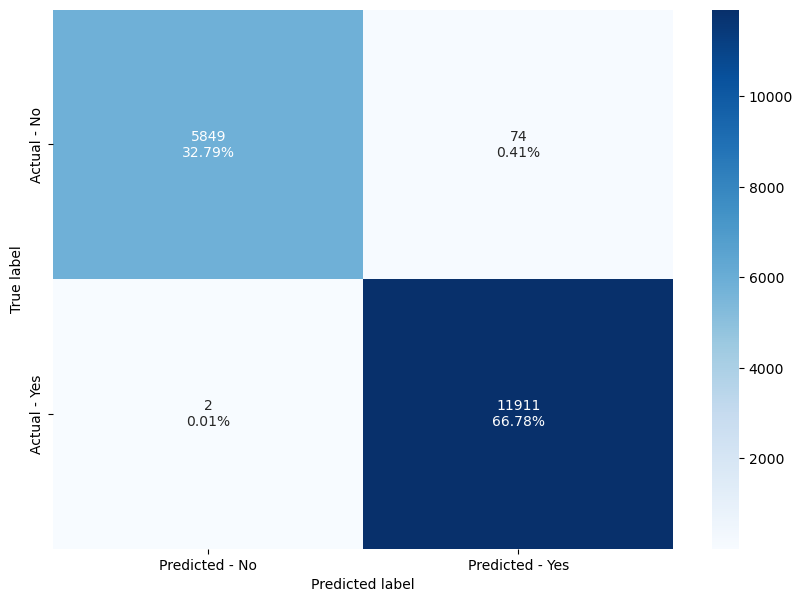

In [213]:
make_confusion_matrix(bagging_tuned1, X_train, y_train,threshold=0.5)

In [215]:
print("Bagging tuned training performance model:")
model_performance_classification_statsmodels(bagging_tuned1, X_train, y_train)

Bagging tuned training performance model:


,Accuracy,Recall,Precision,F1
0,0.995739,0.999832,0.993826,0.99682


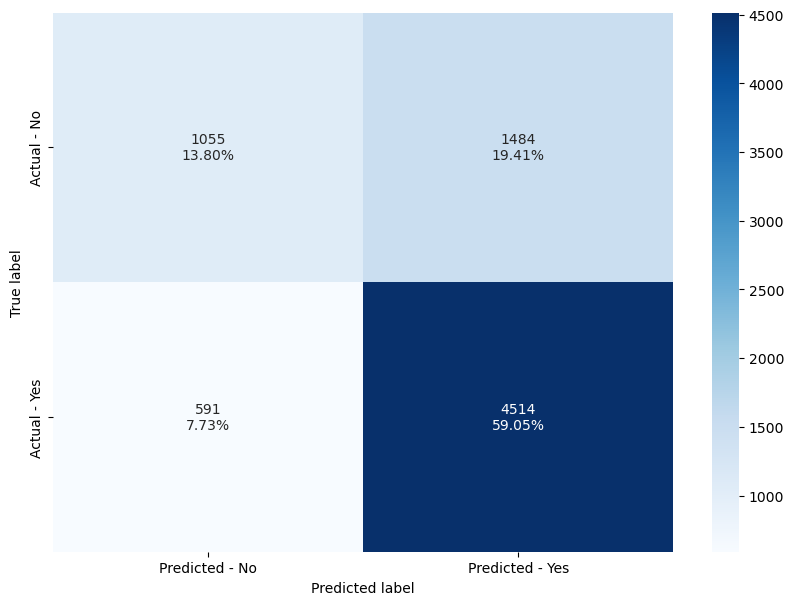

In [217]:
make_confusion_matrix(bagging_tuned1, X_test, y_test,threshold=0.5)

In [187]:
print("Bagging tuned test performance model:")
model_performance_classification_statsmodels(bagging_tuned, X_test, y_test)

Bagging tuned test performance model:


,Accuracy,Recall,Precision,F1
0,0.728022,0.884427,0.751999,0.812854


**Random Forest Classifier-Original data**

In [189]:
# Initialize and train the Random Forest classifier
rf_estimator = RandomForestClassifier(class_weight="balanced", random_state=1)
rf_estimator.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=1)

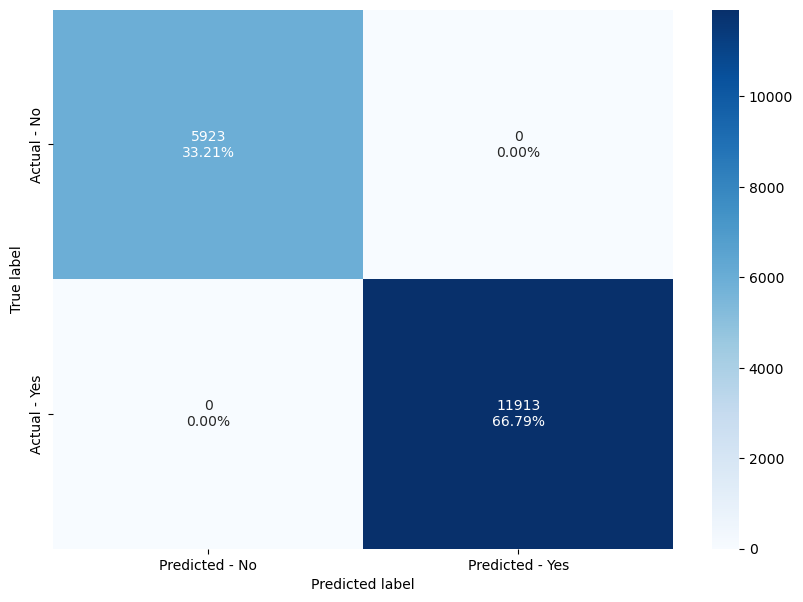

In [191]:
make_confusion_matrix(rf_estimator, X_train, y_train,threshold=0.5)

In [207]:
print("RandomForest Train performance model:")
model_performance_classification_statsmodels(rf_estimator, X_train, y_train)

RandomForest Train performance model:


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


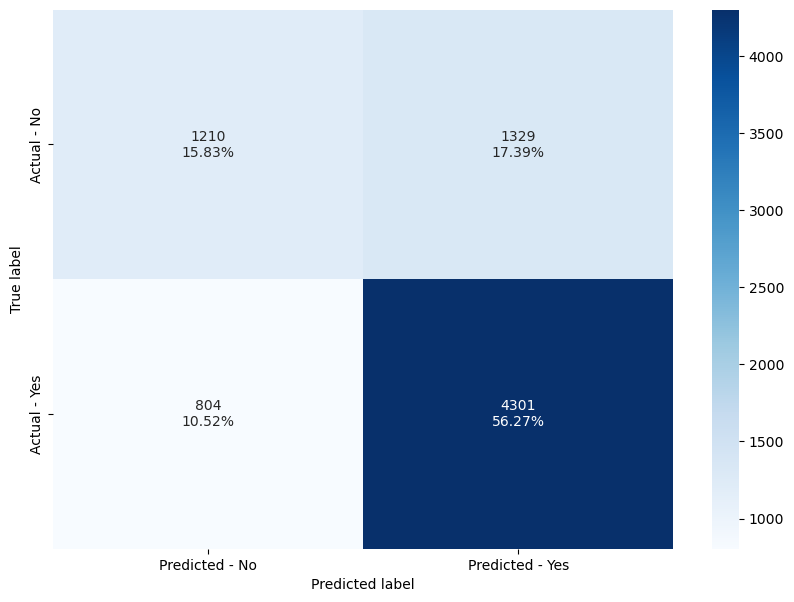

In [195]:
make_confusion_matrix(rf_estimator, X_test, y_test,threshold=0.5)

In [203]:
print("RandomForest Test performance model:")
model_performance_classification_statsmodels(rf_estimator, X_test, y_test)

RandomForest Test performance model:


,Accuracy,Recall,Precision,F1
0,0.720958,0.842507,0.763943,0.801304


In [219]:
RandomForestClassifier().get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [221]:
# Choose the type of classifier.
rf_estimator_tuned = RandomForestClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {"n_estimators": [100, 150, 200],
    "min_samples_leaf": np.arange(5, 10, 20),
    "max_features": np.arange(0.3, 0.5, 0.7),
    "max_samples": np.arange(0.4, 0.6, 0.8),
    "class_weight" : ['balanced', 'balanced_subsample'],
    "max_depth":np.arange(3,4,5),
    "min_impurity_decrease":[0.001, 0.002, 0.003]
             } 

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(rf_estimator_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_estimator_tuned.fit(X_train, y_train)

# Print the best combination of parameters
grid_obj.best_params_
                      

{'class_weight': 'balanced',
 'max_depth': 3,
 'max_features': 0.3,
 'max_samples': 0.4,
 'min_impurity_decrease': 0.002,
 'min_samples_leaf': 5,
 'n_estimators': 100}

In [223]:
# Set the clf to the best combination of parameters
rf_estimator_tuned1 = RandomForestClassifier(
 class_weight='balanced',
 max_depth= 3,
 max_features= 0.3,
 max_samples= 0.4,
 min_impurity_decrease= 0.002,
 min_samples_leaf= 5,
 n_estimators= 100
)

# Fit the best algorithm to the data
rf_estimator_tuned1.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=3, max_features=0.3,
                       max_samples=0.4, min_impurity_decrease=0.002,
                       min_samples_leaf=5)

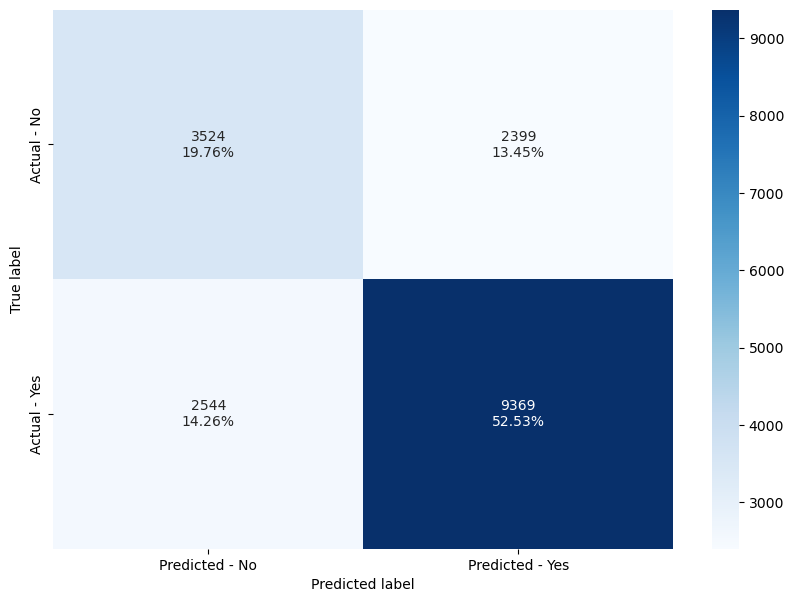

In [225]:
make_confusion_matrix(rf_estimator_tuned1, X_train, y_train,threshold=0.5)

In [227]:
print("RandomForest Tuned Training performance model:")
model_performance_classification_statsmodels(rf_estimator_tuned1, X_train, y_train)

RandomForest Tuned Training performance model:


,Accuracy,Recall,Precision,F1
0,0.722864,0.786452,0.796142,0.791267


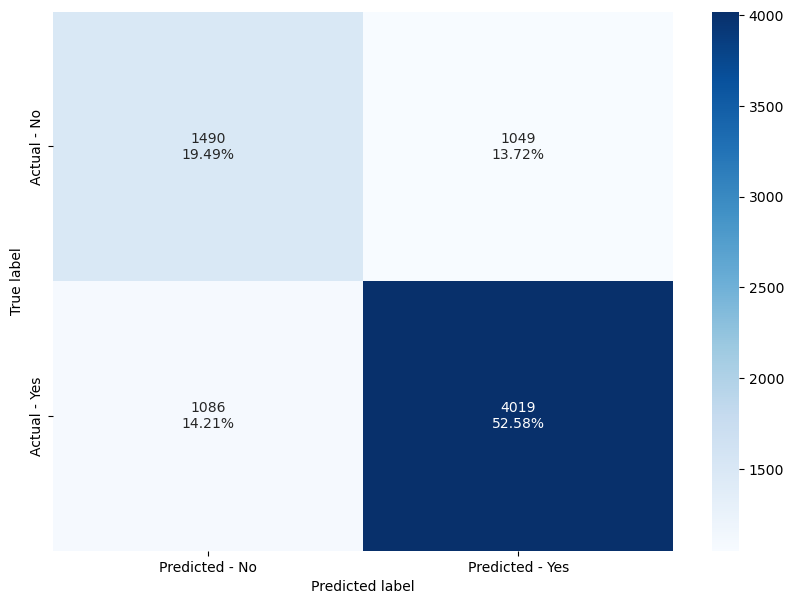

In [229]:
make_confusion_matrix(rf_estimator_tuned1, X_test, y_test,threshold=0.5)

In [231]:
print("RandomForest Tuned Test performance model:")
model_performance_classification_statsmodels(rf_estimator_tuned1, X_test, y_test)

RandomForest Tuned Test performance model:


,Accuracy,Recall,Precision,F1
0,0.720696,0.787267,0.793015,0.790131


**AdaBoost Classifier-Original data**

In [213]:
# Initialize and train the Random AdaBoost Classifier
abc = AdaBoostClassifier(random_state=1)
abc.fit(X_train,y_train)

AdaBoostClassifier(random_state=1)

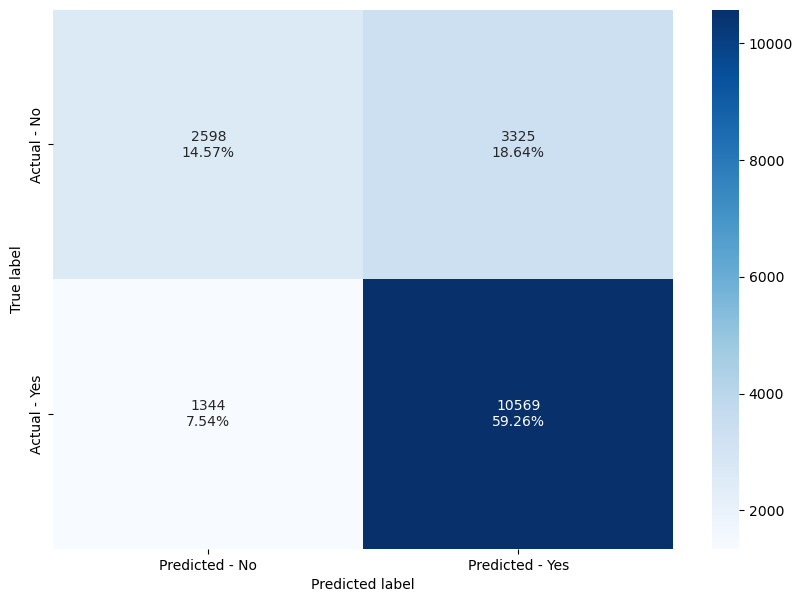

In [215]:
make_confusion_matrix(abc, X_train, y_train,threshold=0.5)

In [221]:
print("AdaBoost Training performance model:")
model_performance_classification_statsmodels(abc, X_train, y_train)

AdaBoost Training performance model:


,Accuracy,Recall,Precision,F1
0,0.738226,0.887182,0.760688,0.81908


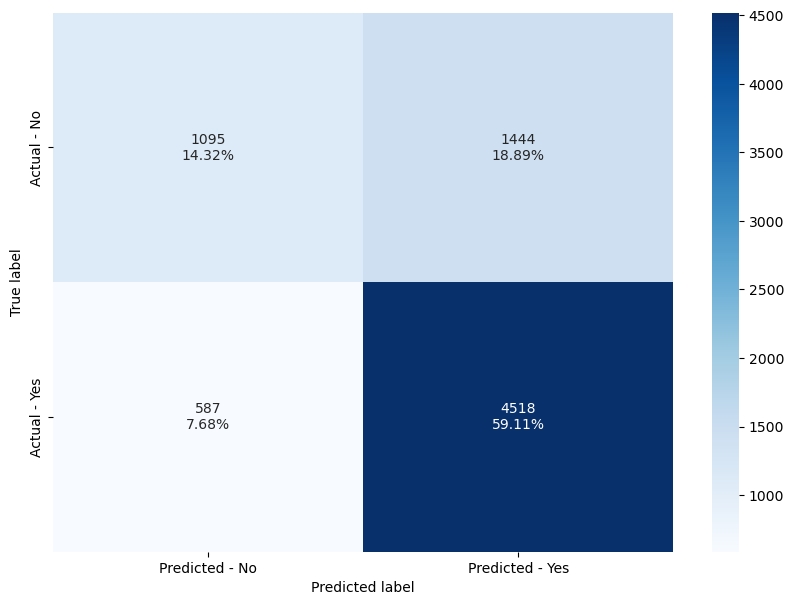

In [219]:
make_confusion_matrix(abc, X_test, y_test,threshold=0.5)

In [223]:
print("AdaBoost Test performance model:")
model_performance_classification_statsmodels(abc, X_test, y_test)

AdaBoost Test performance model:


,Accuracy,Recall,Precision,F1
0,0.734301,0.885015,0.757799,0.816481


In [233]:
AdaBoostClassifier().get_params()

{'algorithm': 'SAMME.R',
 'estimator': None,
 'learning_rate': 1.0,
 'n_estimators': 50,
 'random_state': None}

In [235]:
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    #Let's try different max_depth for base_estimator
    "estimator":[DecisionTreeClassifier(max_depth=1, random_state=1),DecisionTreeClassifier(max_depth=2, random_state=1),DecisionTreeClassifier(max_depth=3, random_state=1)],
    "n_estimators": np.arange(50, 100, 150),
    "learning_rate":np.arange(0.1, 0.4, 0.1)
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(abc_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_train, y_train)

# Print the best combination of parameters
grid_obj.best_params_

{'estimator': DecisionTreeClassifier(max_depth=1, random_state=1),
 'learning_rate': 0.1,
 'n_estimators': 50}

In [239]:
# Set the clf to the best combination of parameters
abc_tuned1 = AdaBoostClassifier(
 estimator = DecisionTreeClassifier(max_depth=1, random_state=1),
 learning_rate= 0.1,
 n_estimators= 50
)

# Fit the best algorithm to the data
abc_tuned1.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=1),
                   learning_rate=0.1)

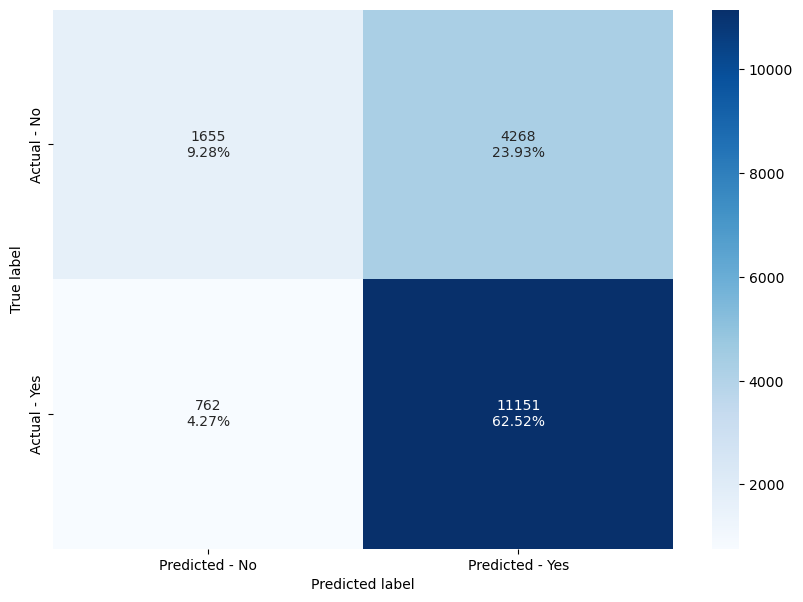

In [241]:
make_confusion_matrix(abc_tuned1, X_train, y_train,threshold=0.5)

In [243]:
print("AdaBoost tuned Train performance model:")
model_performance_classification_statsmodels(abc_tuned1, X_train, y_train)

AdaBoost tuned Train performance model:


,Accuracy,Recall,Precision,F1
0,0.717986,0.936036,0.723199,0.815967


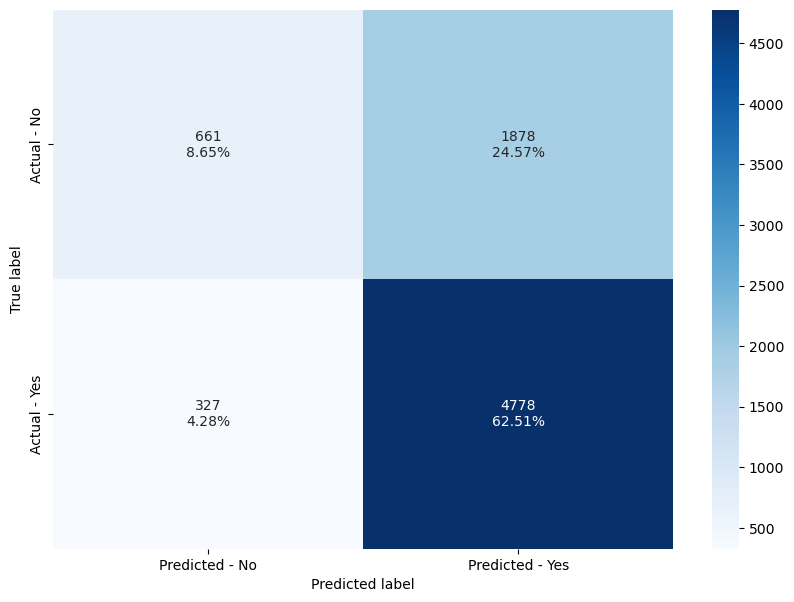

In [245]:
make_confusion_matrix(abc_tuned1, X_test, y_test,threshold=0.5)

In [247]:
print("AdaBoost tuned Test performance model:")
model_performance_classification_statsmodels(abc_tuned1, X_test, y_test)

AdaBoost tuned Test performance model:


,Accuracy,Recall,Precision,F1
0,0.711538,0.935945,0.717849,0.812516


**Gradient Boosting Classifier**

In [217]:
#Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=1)
gbc.fit(X_train,y_train)

GradientBoostingClassifier(random_state=1)

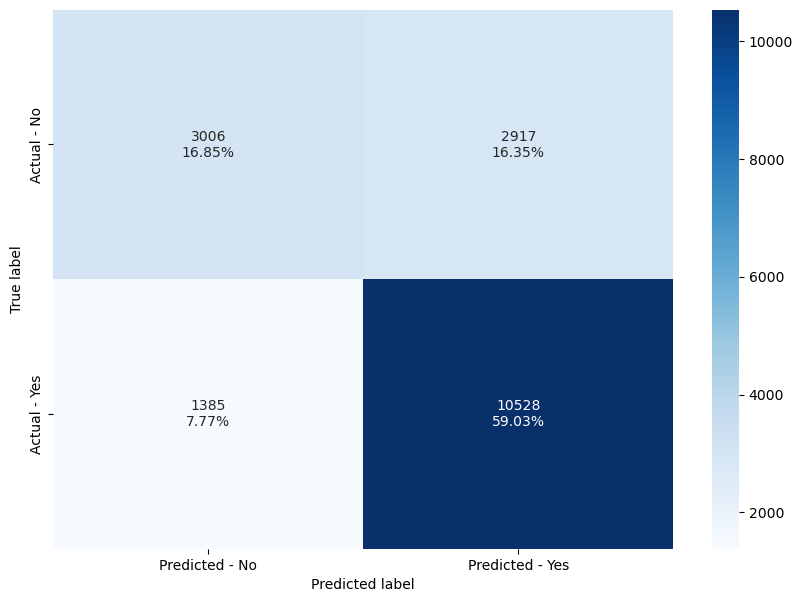

In [219]:
make_confusion_matrix(gbc, X_train, y_train,threshold=0.5)

In [221]:
print("Gradient Boosting Train performance model:")
model_performance_classification_statsmodels(gbc, X_train, y_train)

Gradient Boosting Train performance model:


,Accuracy,Recall,Precision,F1
0,0.758802,0.88374,0.783042,0.830349


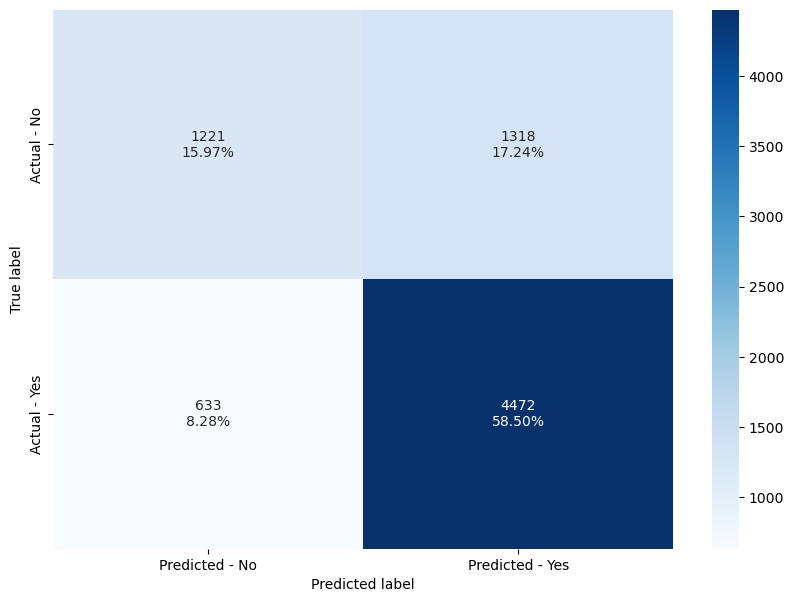

In [223]:
make_confusion_matrix(gbc, X_test, y_test,threshold=0.5)

In [225]:
print("Gradient Boosting Test performance model:")
model_performance_classification_statsmodels(gbc, X_test, y_test)

Gradient Boosting Test performance model:


,Accuracy,Recall,Precision,F1
0,0.744767,0.876004,0.772366,0.820927


In [227]:
GradientBoostingClassifier().get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': None,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [229]:
gbc_tuned = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    "n_estimators": [200, 250],
    "subsample": [0.9, 1],
    "max_features": [0.8, 0.9],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(gbc_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_train, y_train)

# Print the best combination of parameters
grid_obj.best_params_

{'max_features': 0.8, 'n_estimators': 200, 'subsample': 1}

In [231]:
# Set the clf to the best combination of parameters
gbc_tuned1 = GradientBoostingClassifier(
 max_features= 0.8, 
 n_estimators= 200, 
 subsample= 1
)

# Fit the best algorithm to the data
gbc_tuned1.fit(X_train, y_train)

GradientBoostingClassifier(max_features=0.8, n_estimators=200, subsample=1)

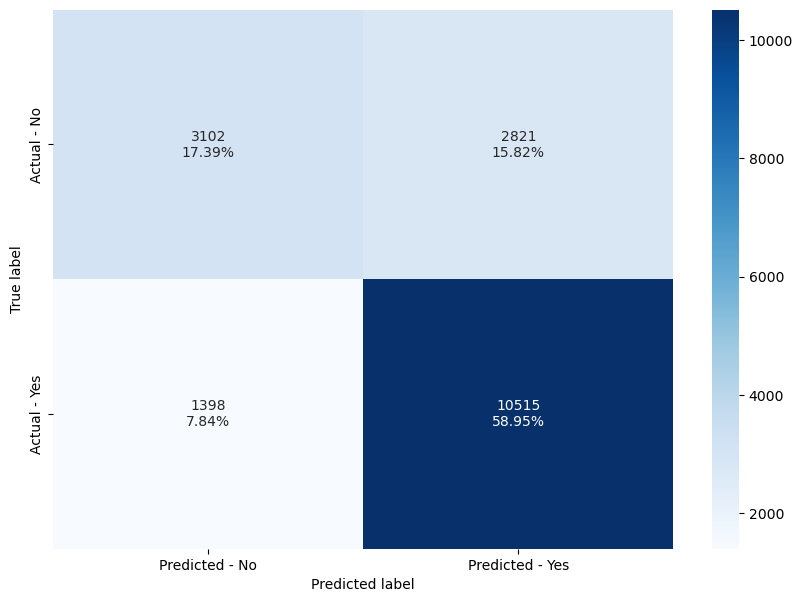

In [257]:
make_confusion_matrix(gbc_tuned1, X_train, y_train,threshold=0.5)

In [259]:
print("Gradient Boosting tuned Training performance model:")
model_performance_classification_statsmodels(gbc_tuned1, X_train, y_train)

Gradient Boosting tuned Training performance model:


,Accuracy,Recall,Precision,F1
0,0.763456,0.882649,0.788467,0.832904


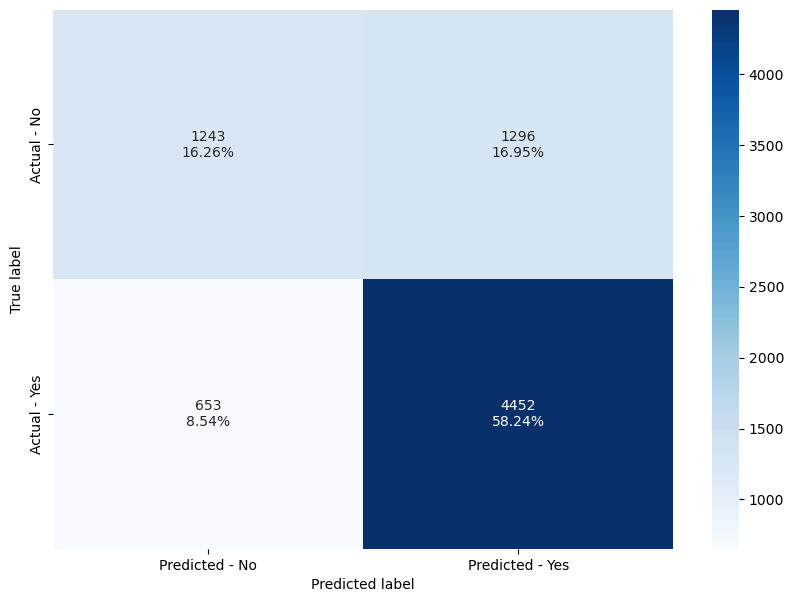

In [261]:
make_confusion_matrix(gbc_tuned1, X_test, y_test,threshold=0.5)

In [263]:
print("Gradient Boosting tuned Training performance model:")
model_performance_classification_statsmodels(gbc_tuned1, X_test, y_test)

Gradient Boosting tuned Training performance model:


,Accuracy,Recall,Precision,F1
0,0.745029,0.872086,0.77453,0.820418


In [190]:
# To undersample and oversample the data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [192]:
# first we split data into 2 parts, say temporary and test
X_train1, X_temp, y_train1, y_temp = train_test_split(
    X, y, test_size=0.5, random_state=0, stratify=y
)

# then we split the temporary set into train and validation
X_val, X_test1, y_val, y_test1 = train_test_split(
    X_temp, y_temp, test_size=0.4, random_state=0, stratify=y_temp
)

print(X_train1.shape, X_val.shape, X_test1.shape)

(12740, 22) (7644, 22) (5096, 22)


In [194]:
# Checking class balance for whole data, train set, validation set, and test set

print("Target value ratio in y")
print(y.value_counts(1))
print("*" * 80)
print("Target value ratio in y_train")
print(y_train1.value_counts(1))
print("*" * 80)
print("Target value ratio in y_val")
print(y_val.value_counts(1))
print("*" * 80)
print("Target value ratio in y_test")
print(y_test1.value_counts(1))
print("*" * 80)

Target value ratio in y
case_status
1    0.667896
0    0.332104
Name: proportion, dtype: float64
********************************************************************************
Target value ratio in y_train
case_status
1    0.667896
0    0.332104
Name: proportion, dtype: float64
********************************************************************************
Target value ratio in y_val
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64
********************************************************************************
Target value ratio in y_test
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64
********************************************************************************


**Decision Tree Classifier- Train,Validation,Test**

In [197]:
#Creating a decision tree and checking its performance
dtree1 = DecisionTreeClassifier(random_state=1, max_depth=4)

# training the decision tree model with oversampled training set
dtree1.fit(X_train1, y_train1)

DecisionTreeClassifier(max_depth=4, random_state=1)

In [177]:
print(pd.DataFrame(dtree1.feature_importances_, columns = ["imp"], index = X_train1.columns))

                                        imp
const                              0.000000
no_of_employees                    0.000000
yr_of_estab                        0.000000
prevailing_wage                    0.242241
continent_Asia                     0.020130
continent_Europe                   0.086819
continent_North America            0.000000
continent_Oceania                  0.000000
continent_South America            0.000000
education_of_employee_Doctorate    0.011196
education_of_employee_High School  0.395502
education_of_employee_Master's     0.049453
has_job_experience_Y               0.159962
requires_job_training_Y            0.000000
region_of_employment_Midwest       0.013072
region_of_employment_Northeast     0.000000
region_of_employment_South         0.006875
region_of_employment_West          0.000000
unit_of_wage_Month                 0.000000
unit_of_wage_Week                  0.000000
unit_of_wage_Year                  0.014752
full_time_position_Y            

In [179]:
# Predicting the target for train and validation set
pred_train = dtree1.predict(X_train1)
pred_val = dtree1.predict(X_val)

In [181]:
# Checking recall score on oversampled train and validation set
print(recall_score(y_train1, pred_train))
print(recall_score(y_val, pred_val))


0.9137383946409684
0.9134182174338883


In [183]:
# Checking accuracy score on oversampled train and validation set
print(accuracy_score(y_train1, pred_train))
print(accuracy_score(y_val, pred_val))

0.7365777080062794
0.7326007326007326


## Oversampling train data using SMOTE

In [103]:
# Fit SMOTE on train data(Synthetic Minority Oversampling Technique)
sm = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train1, y_train1)

In [105]:
print("Before OverSampling, count of label '1': {}".format(sum(y_train1 == 1)))
print("Before OverSampling, count of label '0': {} \n".format(sum(y_train1 == 0)))

print("After OverSampling, count of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, count of label '0': {} \n".format(sum(y_train_over == 0)))

print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, count of label '1': 8509
Before OverSampling, count of label '0': 4231 

After OverSampling, count of label '1': 8509
After OverSampling, count of label '0': 8509 

After OverSampling, the shape of train_X: (17018, 22)
After OverSampling, the shape of train_y: (17018,) 



In [107]:
dtree2 = DecisionTreeClassifier(random_state=1, max_depth=4)

# training the decision tree model with oversampled training set
dtree2.fit(X_train_over, y_train_over)

DecisionTreeClassifier(max_depth=4, random_state=1)

In [45]:
# Predicting the target for train and validation set
pred_train1 = dtree2.predict(X_train_over)
pred_val1 = dtree2.predict(X_val)

In [46]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_over, dtree2.predict(X_train_over)))
print(recall_score(y_val, dtree2.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_over, dtree2.predict(X_train_over)))
print(precision_score(y_val, dtree2.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_over, dtree2.predict(X_train_over)))
print(accuracy_score(y_val, dtree2.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_over, dtree2.predict(X_train_over)))
print(f1_score(y_val, dtree2.predict(X_val)))

Recall on train and validation set
0.9269009284287225
0.929285014691479

Precision on train and validation set
0.6819714656290532
0.7342516638291287

Accuracy on train and validation set
0.7473263603243624
0.728152799581371

F1 Score on train and validation set
0.7857925675002491
0.8203354660210963


In [109]:
#base_estimator for bagging classifier is a decision tree by default
bagging_estimator1=BaggingClassifier(random_state=1)
bagging_estimator1.fit(X_train_over,y_train_over)

BaggingClassifier(random_state=1)

In [111]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_over, bagging_estimator1.predict(X_train_over)))
print(recall_score(y_val, bagging_estimator1.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_over, bagging_estimator1.predict(X_train_over)))
print(precision_score(y_val, bagging_estimator1.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_over, bagging_estimator1.predict(X_train_over)))
print(accuracy_score(y_val, bagging_estimator1.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_over, bagging_estimator1.predict(X_train_over)))
print(f1_score(y_val, bagging_estimator1.predict(X_val)))
                                                       

Recall on train and validation set
0.9828416970266777
0.7755142017629775

Precision on train and validation set
0.9927587844254511
0.7746037957346898

Accuracy on train and validation set
0.987836408508638
0.6993720565149136

F1 Score on train and validation set
0.9877753499084627
0.7750587314017228


In [113]:
#base_estimator for Random forest classifier is a decision tree by default
rf_estimator1 = RandomForestClassifier(class_weight="balanced", random_state=1)
rf_estimator1.fit(X_train_over, y_train_over)

RandomForestClassifier(class_weight='balanced', random_state=1)

In [115]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_over, rf_estimator1.predict(X_train_over)))
print(recall_score(y_val, rf_estimator1.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_over, rf_estimator1.predict(X_train_over)))
print(precision_score(y_val, rf_estimator1.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_over, rf_estimator1.predict(X_train_over)))
print(accuracy_score(y_val, rf_estimator1.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_over, rf_estimator1.predict(X_train_over)))
print(f1_score(y_val, rf_estimator1.predict(X_val)))

Recall on train and validation set
1.0
0.8329089128305582

Precision on train and validation set
1.0
0.7709882139619221

Accuracy on train and validation set
1.0
0.7231815803244375

F1 Score on train and validation set
1.0
0.8007532956685499


In [117]:
#base_estimator for Adaboost classifier is a decision tree by default
abc1 = AdaBoostClassifier(random_state=1)
abc1.fit(X_train_over,y_train_over)

AdaBoostClassifier(random_state=1)

In [119]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_over, abc1.predict(X_train_over)))
print(recall_score(y_val, abc1.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_over, abc1.predict(X_train_over)))
print(precision_score(y_val, abc1.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_over, abc1.predict(X_train_over)))
print(accuracy_score(y_val, abc1.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_over, abc1.predict(X_train_over)))
print(f1_score(y_val, abc1.predict(X_val)))

Recall on train and validation set
0.8785991303325891
0.8859941234084231

Precision on train and validation set
0.7585996955859969
0.7632467094161323

Accuracy on train and validation set
0.7995064049829592
0.7403192046049188

F1 Score on train and validation set
0.8142016989762579
0.820052579095277


In [121]:
#Gradient Boosting Classifier
gbc1 = GradientBoostingClassifier(random_state=1)
gbc1.fit(X_train_over,y_train_over)

GradientBoostingClassifier(random_state=1)

In [123]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_over, gbc1.predict(X_train_over)))
print(recall_score(y_val, gbc1.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_over, gbc1.predict(X_train_over)))
print(precision_score(y_val, gbc1.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_over, gbc1.predict(X_train_over)))
print(accuracy_score(y_val, gbc1.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_over, gbc1.predict(X_train_over)))
print(f1_score(y_val, gbc1.predict(X_val)))

Recall on train and validation set
0.8626160535903161
0.8669931439764936

Precision on train and validation set
0.786962581751903
0.7864250177683013

Accuracy on train and validation set
0.8145493007403926
0.7539246467817896

F1 Score on train and validation set
0.8230544965238843
0.8247461101276438


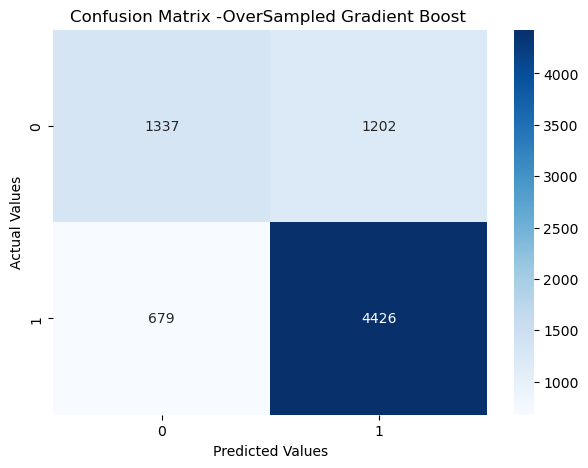

In [125]:
# create confusion matrix
cm = confusion_matrix(y_val, gbc1.predict(X_val))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix -OverSampled Gradient Boost ")
plt.show()

In [127]:
gbc_tuned_over = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    "n_estimators": [200, 250],
    "subsample": [0.9, 1],
    "max_features": [0.8, 0.9],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(gbc_tuned_over, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
gbc_tuned_over = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned_over.fit(X_train_over, y_train_over)

# Print the best combination of parameters
grid_obj.best_params_

{'max_features': 0.9, 'n_estimators': 200, 'subsample': 1}

In [129]:
# Set the clf to the best combination of parameters
gbc_tuned_over1 = GradientBoostingClassifier(
 max_features= 0.9, 
 n_estimators= 200, 
 subsample= 1
)

# Fit the best algorithm to the data
gbc_tuned_over1.fit(X_train_over, y_train_over)

GradientBoostingClassifier(max_features=0.9, n_estimators=200, subsample=1)

In [131]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_over, gbc_tuned_over1.predict(X_train_over)))
print(recall_score(y_val, gbc_tuned_over1.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_over, gbc_tuned_over1.predict(X_train_over)))
print(precision_score(y_val, gbc_tuned_over1.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_over, gbc_tuned_over1.predict(X_train_over)))
print(accuracy_score(y_val, gbc_tuned_over1.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_over, gbc_tuned_over1.predict(X_train_over)))
print(f1_score(y_val, gbc_tuned_over1.predict(X_val)))

Recall on train and validation set
0.8684921847455636
0.8693437806072478

Precision on train and validation set
0.7907972177635099
0.7842374977911292

Accuracy on train and validation set
0.8193677282876953
0.7530088958660387

F1 Score on train and validation set
0.8278256973227288
0.8246005202526941


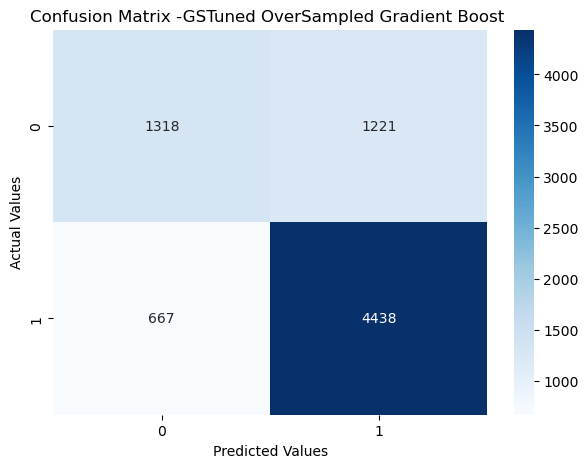

In [133]:
# Confusion matrix for validation data
pred_gb = gbc_tuned_over1.predict(X_val)       # Gradient Boosting


# Now create confusion matrix
cm = confusion_matrix(y_val, pred_gb)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix -GSTuned OverSampled Gradient Boost ")
plt.show()

In [135]:
# Checking recall score on test set
print("Recall on test set")
print(recall_score(y_test1, gbc_tuned_over1.predict(X_test1)))
print("")

# Checking precision score on test set
print("Precision on test set")
print(precision_score(y_test1, gbc_tuned_over1.predict(X_test1)))
print("")

# Checking accuracy score on test set
print("Accuracy on test set")
print(accuracy_score(y_test1, gbc_tuned_over1.predict(X_test1)))

print("")

# Checking accuracy F1 on test set
print("F1 on test set")
print(f1_score(y_test1, gbc_tuned_over1.predict(X_test1)))

Recall on test set
0.8622209165687427

Precision on test set
0.7778955738139411

Accuracy on test set
0.7435243328100472

F1 on test set
0.8178904834889229


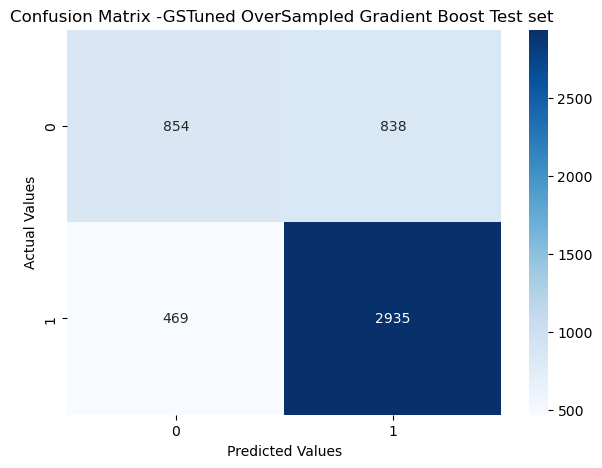

In [139]:
# Now create confusion matrix on Test data
cm = confusion_matrix(y_test1, gbc_tuned_over1.predict(X_test1))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix -GSTuned OverSampled Gradient Boost Test set ")
plt.show()

## Undersampling train data using Random Undersampler

In [232]:
# fit random under sampler on the train data
rus = RandomUnderSampler(random_state=1, sampling_strategy = 1)
X_train_un, y_train_un = rus.fit_resample(X_train1, y_train1)

In [234]:
print("Before Under Sampling, count of label '1': {}".format(sum(y_train1 == 1)))
print("Before Under Sampling, count of label '0': {} \n".format(sum(y_train1 == 0)))

print("After Under Sampling, count of label '1': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, count of label '0': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, count of label '1': 8509
Before Under Sampling, count of label '0': 4231 

After Under Sampling, count of label '1': 4231
After Under Sampling, count of label '0': 4231 

After Under Sampling, the shape of train_X: (8462, 22)
After Under Sampling, the shape of train_y: (8462,) 



In [134]:
dtree3 = DecisionTreeClassifier(random_state=1, max_depth=4)

# training the decision tree model with undersampled training set
dtree3.fit(X_train_un, y_train_un)

DecisionTreeClassifier(max_depth=4, random_state=1)

In [135]:
# Predicting the target for train and validation set
pred_train2 = dtree3.predict(X_train_un)
pred_val2 = dtree3.predict(X_val)

In [136]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_un, dtree3.predict(X_train_un)))
print(recall_score(y_val, dtree3.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_un, dtree3.predict(X_train_un)))
print(precision_score(y_val, dtree3.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_un, dtree3.predict(X_train_un)))
print(accuracy_score(y_val, dtree3.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_un, dtree3.predict(X_train_un)))
print(f1_score(y_val, dtree3.predict(X_val)))

Recall on train and validation set
0.6650909950366344
0.6803134182174339

Precision on train and validation set
0.6825127334465195
0.8114485981308411

Accuracy on train and validation set
0.677853935239896
0.6809262166405023

F1 Score on train and validation set
0.6736892506583673
0.7401172083111348


In [138]:
#base_estimator for bagging classifier is a decision tree by default
bagging_estimator2=BaggingClassifier(random_state=1)
bagging_estimator2.fit(X_train_un,y_train_un)

BaggingClassifier(random_state=1)

In [139]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_un, bagging_estimator2.predict(X_train_un)))
print(recall_score(y_val, bagging_estimator2.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_un, bagging_estimator2.predict(X_train_un)))
print(precision_score(y_val, bagging_estimator2.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_un, bagging_estimator2.predict(X_train_un)))
print(accuracy_score(y_val, bagging_estimator2.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_un, bagging_estimator2.predict(X_train_un)))
print(f1_score(y_val, bagging_estimator2.predict(X_val)))

Recall on train and validation set
0.9697471047033798
0.6107737512242899

Precision on train and validation set
0.9910628019323672
0.8094496365524403

Accuracy on train and validation set
0.9805010635783503
0.6440345368916798

F1 Score on train and validation set
0.9802890932982917
0.696215250641956


In [140]:
#base_estimator for Random forest classifier is a decision tree by default
rf_estimator2 = RandomForestClassifier(class_weight="balanced", random_state=1)
rf_estimator2.fit(X_train_un, y_train_un)

RandomForestClassifier(class_weight='balanced', random_state=1)

In [142]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_un, rf_estimator2.predict(X_train_un)))
print(recall_score(y_val, rf_estimator2.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_un, rf_estimator2.predict(X_train_un)))
print(precision_score(y_val, rf_estimator2.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_un, rf_estimator2.predict(X_train_un)))
print(accuracy_score(y_val, rf_estimator2.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_un, rf_estimator2.predict(X_train_un)))
print(f1_score(y_val, rf_estimator2.predict(X_val)))

Recall on train and validation set
1.0
0.6787463271302644

Precision on train and validation set
1.0
0.8181818181818182

Accuracy on train and validation set
1.0
0.684720041862899

F1 Score on train and validation set
1.0
0.7419700214132763


In [143]:
#base_estimator for Adaboost classifier is a decision tree by default
abc2 = AdaBoostClassifier(random_state=1)
abc2.fit(X_train_un,y_train_un)

AdaBoostClassifier(random_state=1)

In [144]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_un, abc2.predict(X_train_un)))
print(recall_score(y_val, abc2.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_un, abc2.predict(X_train_un)))
print(precision_score(y_val, abc2.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_un, abc2.predict(X_train_un)))
print(accuracy_score(y_val, abc2.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_un, abc2.predict(X_train_un)))
print(f1_score(y_val, abc2.predict(X_val)))

Recall on train and validation set
0.709997636492555
0.7165523996082273

Precision on train and validation set
0.6952094422587364
0.8136120996441281

Accuracy on train and validation set
0.6993618529898369
0.7010727367870225

F1 Score on train and validation set
0.7025257249766137
0.7620039579210499


In [279]:
#Gradient Boosting Classifier
gbc2 = GradientBoostingClassifier(random_state=1)
gbc2.fit(X_train_un,y_train_un)

GradientBoostingClassifier(random_state=1)

In [281]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_un, gbc2.predict(X_train_un)))
print(recall_score(y_val, gbc2.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_un, gbc2.predict(X_train_un)))
print(precision_score(y_val, gbc2.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_un, gbc2.predict(X_train_un)))
print(accuracy_score(y_val, gbc2.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_un, gbc2.predict(X_train_un)))
print(f1_score(y_val, gbc2.predict(X_val)))

Recall on train and validation set
0.7218151737177972
0.7102840352595494

Precision on train and validation set
0.7243833017077799
0.8263445761166819

Accuracy on train and validation set
0.7235878043015835
0.706828885400314

F1 Score on train and validation set
0.723096957499704
0.7639313178131255


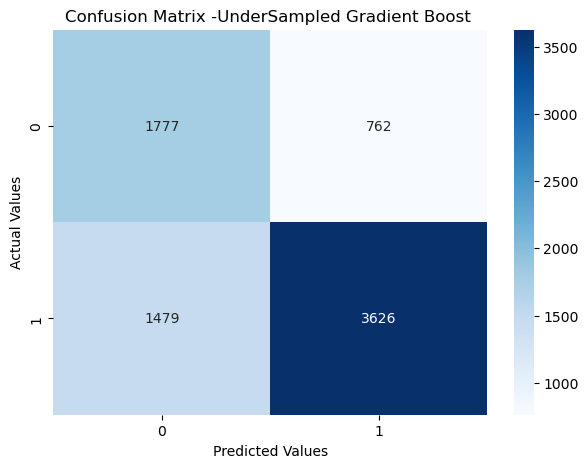

In [295]:
# Now create confusion matrix
cm = confusion_matrix(y_val, gbc2.predict(X_val))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix -UnderSampled Gradient Boost ")
plt.show()

In [283]:
gbc_tuned_under = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    "n_estimators": [200, 250],
    "subsample": [0.9, 1],
    "max_features": [0.8, 0.9],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(gbc_tuned_under, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train_un, y_train_un)

# Set the clf to the best combination of parameters
gbc_tuned_under = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned_under.fit(X_train_un, y_train_un)

# Print the best combination of parameters
grid_obj.best_params_

{'max_features': 0.9, 'n_estimators': 250, 'subsample': 0.9}

In [285]:
# Set the clf to the best combination of parameters
gbc_tuned_under1 = GradientBoostingClassifier(
 max_features= 0.9, 
 n_estimators= 250, 
 subsample= 0.9
)

# Fit the best algorithm to the data
gbc_tuned_under1.fit(X_train_un, y_train_un)

GradientBoostingClassifier(max_features=0.9, n_estimators=250, subsample=0.9)

In [287]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_un, gbc_tuned_under1.predict(X_train_un)))
print(recall_score(y_val, gbc_tuned_under1.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_un, gbc_tuned_under1.predict(X_train_un)))
print(precision_score(y_val, gbc_tuned_under1.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_un, gbc_tuned_under1.predict(X_train_un)))
print(accuracy_score(y_val, gbc_tuned_under1.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_un, gbc_tuned_under1.predict(X_train_un)))
print(f1_score(y_val, gbc_tuned_under1.predict(X_val)))

Recall on train and validation set
0.7518317182699126
0.7024485798237022

Precision on train and validation set
0.7541488857278331
0.8239889705882353

Accuracy on train and validation set
0.7533679981091941
0.7010727367870225

F1 Score on train and validation set
0.7529885193514025
0.7583800359522047


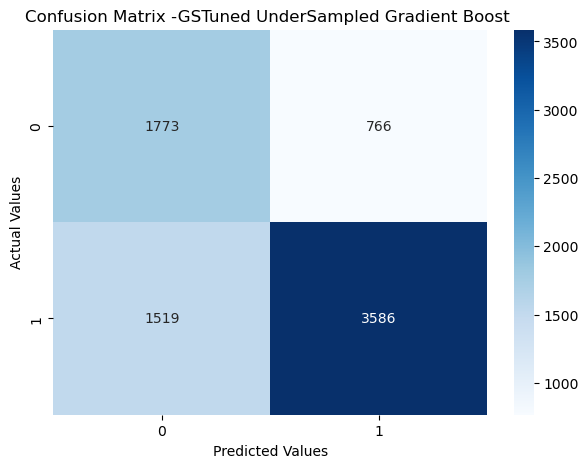

In [291]:
# Confusion matrix for validation data
pred_gb1 = gbc_tuned_under1.predict(X_val)       # Gradient Boosting


# Now create confusion matrix
cm = confusion_matrix(y_val, pred_gb1)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix -GSTuned UnderSampled Gradient Boost ")
plt.show()

##**Randomized Search CV**

##**tuning Gradient boost of original data using Randomized Search**

In [199]:
from sklearn.model_selection import RandomizedSearchCV

In [201]:
# Choose the type of classifier. 
gbr = GradientBoostingClassifier(random_state=1)

# Grid of parameters to choose from
parameters = { "n_estimators": [200, 250],
    "subsample": [0.9, 1],
    "max_features": [0.8, 0.9],
             }

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the random search
grid_obj = RandomizedSearchCV(gbr, parameters,n_iter=30, scoring=acc_scorer,cv=5, random_state = 1, n_jobs = -1, verbose = 2)
# using n_iter = 30, so randomized search will try 30 different combinations of hyperparameters
# by default, n_iter = 10

grid_obj = grid_obj.fit(X_train, y_train)

# Print the best combination of parameters
grid_obj.best_params_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


{'subsample': 1, 'n_estimators': 200, 'max_features': 0.9}

In [203]:
# Set the clf to the best combination of parameters
gbr_tuned = GradientBoostingClassifier(
    subsample= 1, n_estimators= 200, max_features= 0.9
)

# Fit the best algorithm to the data.
gbr_tuned.fit(X_train, y_train)

GradientBoostingClassifier(max_features=0.9, n_estimators=200, subsample=1)

In [204]:
print("Gradient Boosting tuned Training performance model:")
model_performance_classification_statsmodels(gbr_tuned, X_train, y_train)

Gradient Boosting tuned Training performance model:


,Accuracy,Recall,Precision,F1
0,0.763176,0.882901,0.788042,0.832779


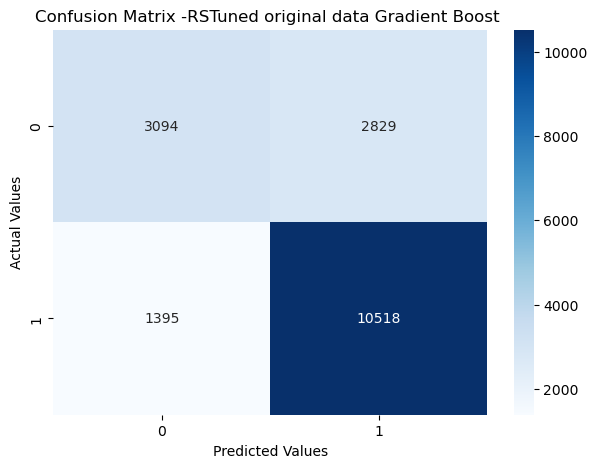

In [207]:
#create confusion matrix
cm = confusion_matrix(y_train, gbr_tuned.predict(X_train))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix -RSTuned original data Gradient Boost ")
plt.show()

In [209]:
print("Gradient Boosting tuned Test performance model:")
model_performance_classification_statsmodels(gbr_tuned, X_test, y_test)

Gradient Boosting tuned Test performance model:


,Accuracy,Recall,Precision,F1
0,0.745421,0.872282,0.774839,0.820678


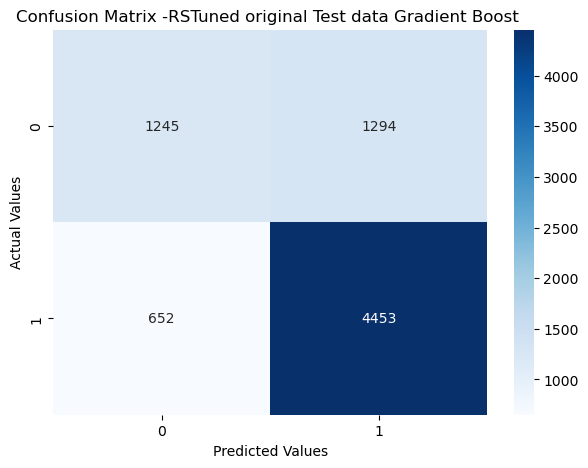

In [215]:
#create confusion matrix
cm = confusion_matrix(y_test, gbr_tuned.predict(X_test))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix -RSTuned original Test data Gradient Boost ")
plt.show()

##**tuning Gradient boost of OverSampled data using Randomized Search**

In [313]:
# Choose the type of classifier. 
gbr_over = GradientBoostingClassifier(random_state=1)

# Grid of parameters to choose from
parameters = { "n_estimators": [200, 250],
    "subsample": [0.9, 1],
    "max_features": [0.8, 0.9],
             }

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the random search
grid_obj = RandomizedSearchCV(gbr_over, parameters,n_iter=30, scoring=acc_scorer,cv=5, random_state = 1, n_jobs = -1, verbose = 2)
# using n_iter = 30, so randomized search will try 30 different combinations of hyperparameters
# by default, n_iter = 10

grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Print the best combination of parameters
grid_obj.best_params_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


{'subsample': 1, 'n_estimators': 200, 'max_features': 0.8}

In [314]:
# Set the clf to the best combination of parameters
gbr_over_tuned = GradientBoostingClassifier(
    subsample= 1, n_estimators= 200, max_features= 0.8
)

# Fit the best algorithm to the data.
gbr_over_tuned.fit(X_train_over, y_train_over)

GradientBoostingClassifier(max_features=0.8, n_estimators=200, subsample=1)

In [317]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_over, gbr_over_tuned.predict(X_train_over)))
print(recall_score(y_val, gbr_over_tuned.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_over, gbr_over_tuned.predict(X_train_over)))
print(precision_score(y_val, gbr_over_tuned.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_over, gbr_over_tuned.predict(X_train_over)))
print(accuracy_score(y_val, gbr_over_tuned.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_over, gbr_over_tuned.predict(X_train_over)))
print(f1_score(y_val, gbr_over_tuned.predict(X_val)))

Recall on train and validation set
0.8699024562228229
0.8713026444662096

Precision on train and validation set
0.7912346338856227
0.7850335333568655

Accuracy on train and validation set
0.82019038664943
0.7547095761381476

F1 Score on train and validation set
0.828705776981639
0.8259214557608393


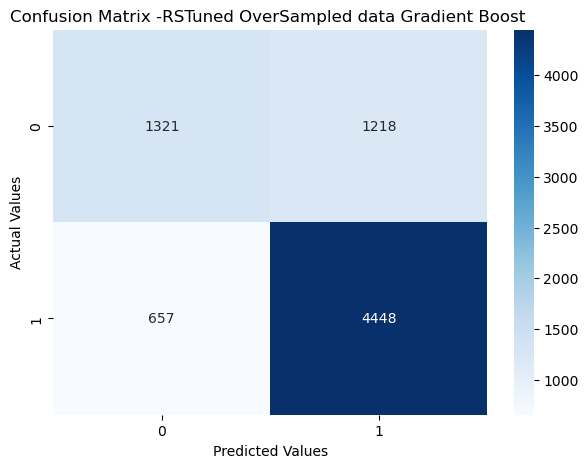

In [323]:
#create confusion matrix
cm = confusion_matrix(y_val, gbr_over_tuned.predict(X_val))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix -RSTuned OverSampled data Gradient Boost ")
plt.show()

##**tuning Gradient boost of UnderSampled data using Randomized Search**

In [236]:
# Choose the type of classifier. 
gbr_under = GradientBoostingClassifier(random_state=1)

# Grid of parameters to choose from
parameters = { "n_estimators": [200, 250],
    "subsample": [0.9, 1],
    "max_features": [0.8, 0.9],
             }

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the random search
grid_obj = RandomizedSearchCV(gbr_under, parameters,n_iter=30, scoring=acc_scorer,cv=5, random_state = 1, n_jobs = -1, verbose = 2)
# using n_iter = 30, so randomized search will try 30 different combinations of hyperparameters
# by default, n_iter = 10

grid_obj = grid_obj.fit(X_train_un, y_train_un)

# Print the best combination of parameters
grid_obj.best_params_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


{'subsample': 0.9, 'n_estimators': 200, 'max_features': 0.8}

In [238]:
# Set the clf to the best combination of parameters
gbr_under_tuned = GradientBoostingClassifier(
    subsample= 1, n_estimators= 200, max_features= 0.8
)

# Fit the best algorithm to the data.
gbr_under_tuned.fit(X_train_un, y_train_un)

GradientBoostingClassifier(max_features=0.8, n_estimators=200, subsample=1)

In [246]:
# Checking recall score on train and validation set
print("Recall on train and validation set")
print(recall_score(y_train_un, gbr_under_tuned.predict(X_train_un)))
print(recall_score(y_val, gbr_under_tuned.predict(X_val)))
print("")

# Checking Precision score on train and validation set
print("Precision on train and validation set")
print(precision_score(y_train_un, gbr_under_tuned.predict(X_train_un)))
print(precision_score(y_val, gbr_under_tuned.predict(X_val)))

print("")

# Checking Accuracy score on train and validation set
print("Accuracy on train and validation set")
print(accuracy_score(y_train_un, gbr_under_tuned.predict(X_train_un)))
print(accuracy_score(y_val, gbr_under_tuned.predict(X_val)))

print("")

# Checking F1 score on train and validation set                    
print("F1 Score on train and validation set")
print(f1_score(y_train_un, gbr_under_tuned.predict(X_train_un)))
print(f1_score(y_val, gbr_under_tuned.predict(X_val)))

Recall on train and validation set
0.7390687780666509
0.7071498530852106

Precision on train and validation set
0.7436385255648038
0.8260869565217391

Accuracy on train and validation set
0.7421413377452138
0.7049973835688121

F1 Score on train and validation set
0.7413466097676624
0.7620052770448549


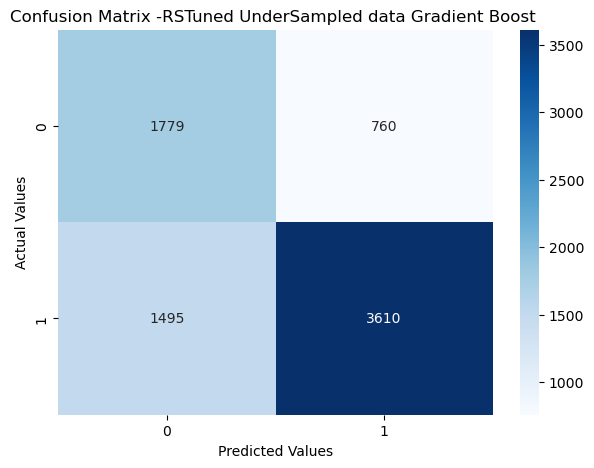

In [325]:
#create confusion matrix
cm = confusion_matrix(y_val, gbr_under_tuned.predict(X_val))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix -RSTuned UnderSampled data Gradient Boost ")
plt.show()

##**Among all the over/under sampled tuned models,OverSmapled Gradient Boost with Random search tuned model performing well on all metrics**

In [329]:
#Checking model on test data
model = gbr_over_tuned

In [331]:
# Checking recall score on test set
print("Recall on test set")
print(recall_score(y_test1, model.predict(X_test1)))
print("")

# Checking precision score on test set
print("Precision on test set")
print(precision_score(y_test1, model.predict(X_test1)))
print("")

# Checking accuracy score on test set
print("Accuracy on test set")
print(accuracy_score(y_test1, model.predict(X_test1)))

print("")

# Checking accuracy F1 on test set
print("F1 on test set")
print(f1_score(y_test1, model.predict(X_test1)))

Recall on test set
0.8607520564042304

Precision on test set
0.7784272051009564

Accuracy on test set
0.7433281004709577

F1 on test set
0.8175223214285714


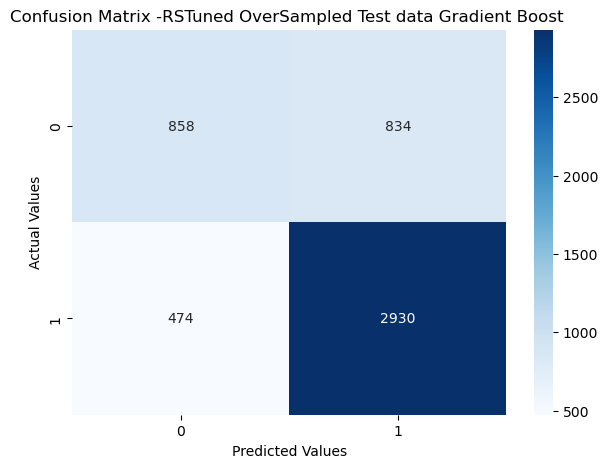

In [337]:
#create confusion matrix
cm = confusion_matrix(y_test1, model.predict(X_test1))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix -RSTuned OverSampled Test data Gradient Boost ")
plt.show()

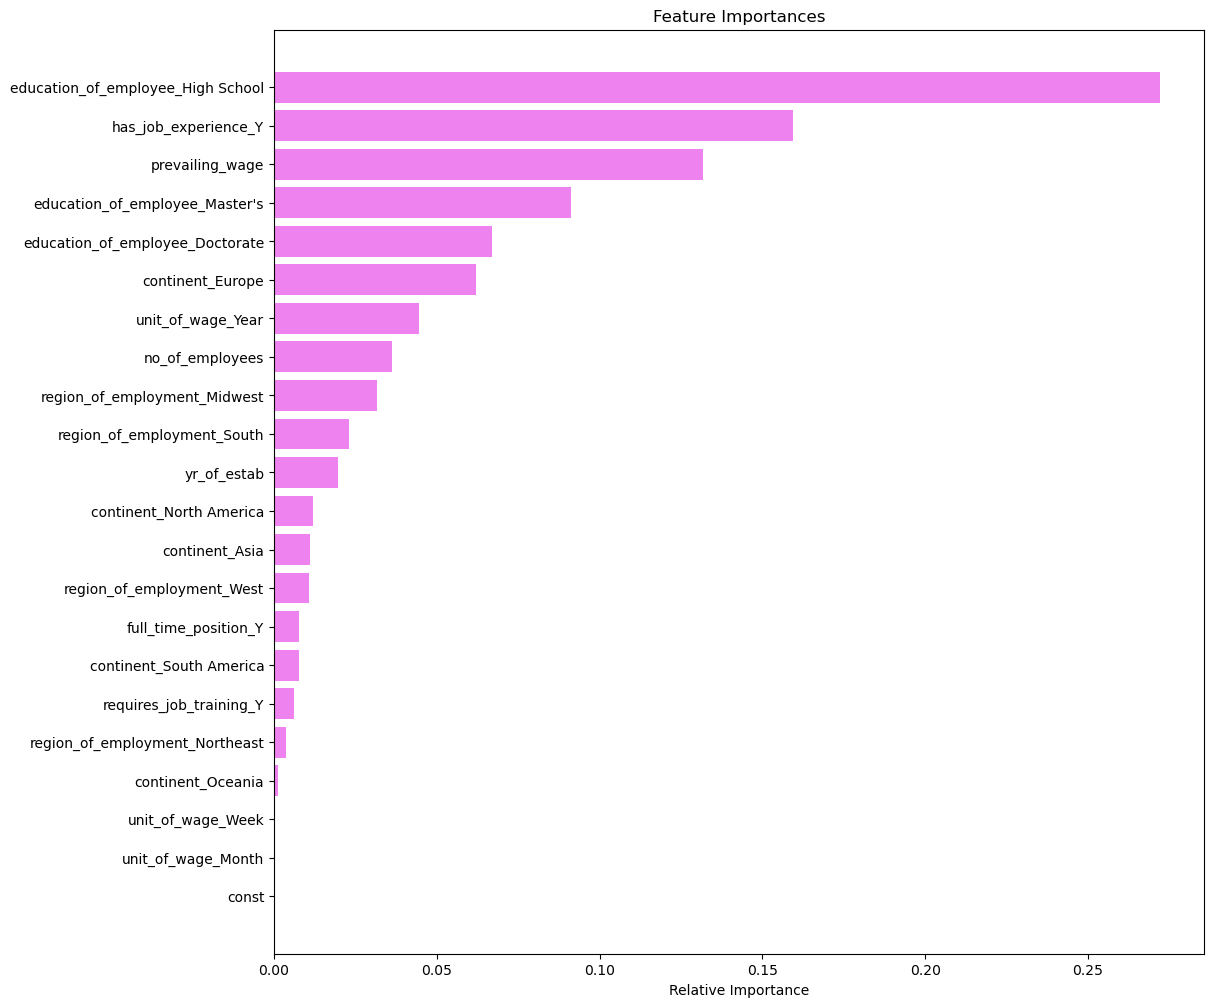

In [233]:
#Feature importance of selected model
importances = gbc_tuned1.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()